[Watch] shape=(15600, 5), columns=['TIMESTAMP', 'TIME', 'GREEN', 'IR', 'RED']
[Watch] Time range: 2026-01-02 09:45:58.273000 ~ 2026-01-02 09:56:24.327000
[Watch] fs_eff ~ 25.00 Hz (nominal 25.0 Hz)
[Ring] shape=(123736, 2), time_col=0, ppg_col=1
[Ring] Time range: 2026-01-02 09:45:58.273000 ~ 2026-01-02 09:56:11.802051
[Ring] fs_eff ~ 184.81 Hz (nominal 200.0 Hz)

[Common Overlap] 2026-01-02 09:45:58.273000 ~ 2026-01-02 09:56:11.802051 (613.5s)
[Selected 10-min Window] 2026-01-02 09:45:58.273000 ~ 2026-01-02 09:55:58.273000

[10-min Cut]
  Watch: 14950 samples, ~598.0s @ 25.00Hz
  Watch: 14950 samples, 600.0s @ 25.00Hz
  Ring : 121004 samples, 600.0s @ 184.81Hz

[Extracting beat features...]
  Watch beats: 867
  Ring  beats: 917

[Aligned bins] n=60 (bin=10s)

[Result: Watch vs Ring Correlation on 10-min window]
  HR  : n= 60, r=-0.153
  AMP : n= 60, r=+0.434

[Plot saved: ppg_watch_ring_10min_comparison.png]


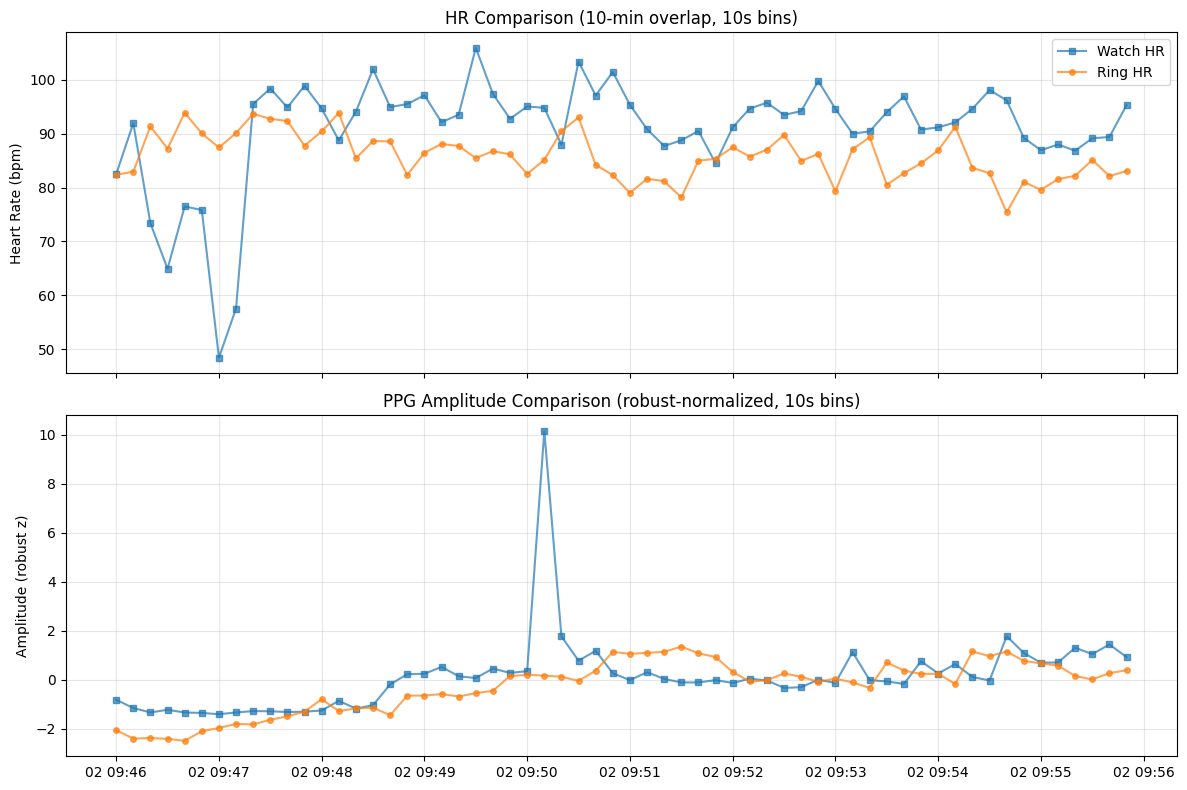

[Results saved: ppg_watch_ring_10min_results.csv]

Analysis Complete!


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks

# ============================================================
# CONFIG (Uploaded sample paths)
# ============================================================
WATCH_CSV = "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0011/25hz/PPG25_on_demand_1767347157625.csv"
RING_CSV  = "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0011/25hz/ppgRaw.csv"

FS_WATCH_NOMINAL = 25.0
FS_RING_NOMINAL  = 200.0   # 참고용(타임스탬프 기반으로 실효 fs도 추정)

# Watch columns
WATCH_TIME_COL = "TIMESTAMP"   # epoch ms
WATCH_PPG_COL  = "GREEN"       # GREEN / IR / RED 중 선택

# Ring columns (ppgRaw.csv는 보통 header 없음 -> 0: time, 1: ppg)
RING_TIME_COL_CANDIDATES = ["time", "Time", "timestamp", "Timestamp", "t", "index", "Index", 0]
RING_PPG_COL_CANDIDATE = 1      # 2열 파일 기준

# Beat / Filter params
MIN_BPM = 40
MAX_BPM = 200
PROM_SCALE_RING  = 0.20
PROM_SCALE_WATCH = 0.10

# 비교용 집계 bin
AGG_BIN_SEC = 10   # 10초 bin 평균으로 HR/AMP 비교

# 정확히 10분 구간
TARGET_MINUTES = 10


# ============================================================
# UTIL
# ============================================================

def preprocess_outlier_ppg(x, fs, hampel_sec=0.5, hampel_k=4.0, winsor_k=6.0):
    x = np.asarray(x, dtype=float)
    if len(x) < 10 or not np.isfinite(fs) or fs <= 1:
        return x.copy()

    s = pd.Series(x)

    win = int(max(5, round(fs * hampel_sec)))
    if win % 2 == 0:
        win += 1

    med = s.rolling(win, center=True, min_periods=max(3, win // 3)).median()
    resid = (s - med).abs()
    mad = resid.rolling(win, center=True, min_periods=max(3, win // 3)).median()

    sigma = 1.4826 * mad
    thr = hampel_k * sigma

    out = resid > thr
    s_h = s.copy()
    s_h[out] = med[out]

    m0 = np.nanmedian(s_h.values)
    mad0 = _robust_mad(s_h.values)
    lo = m0 - winsor_k * mad0
    hi = m0 + winsor_k * mad0
    x_w = np.clip(s_h.values, lo, hi)
    return x_w.astype(float)


def read_csv_robust(path: str) -> pd.DataFrame:
    """CSV 읽기 - 헤더 자동 감지 (첫 행이 숫자 헤더처럼 보이면 header=None 재로드)"""
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except:
            return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def pick_time_col(df: pd.DataFrame, candidates) -> str:
    """시간 컬럼 선택(문자열 또는 인덱스 가능)"""
    for c in candidates:
        if isinstance(c, int):
            if c < df.shape[1]:
                return df.columns[c]
        else:
            if c in df.columns:
                return c
    return df.columns[0]

def preprocess_ppg(x: np.ndarray, fs: float) -> np.ndarray:
    """detrend + bandpass (짧은 신호 예외처리 포함)"""
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(x) < 50:
        return x - np.mean(x)

    try:
        x0 = detrend(x)

        nyq = 0.5 * fs
        lo = max((MIN_BPM/60.0) / nyq, 1e-6)
        hi = min((MAX_BPM/60.0) / nyq, 0.999)
        b, a = butter(2 if fs < 50 else 4, [lo, hi], btype="band")

        default_padlen = 3 * max(len(b), len(a))
        if len(x0) <= default_padlen:
            if len(x0) <= 2 * len(b):
                return x0
            padlen = min(default_padlen, len(x0) - 1)
            return filtfilt(b, a, x0, padlen=padlen)

        return filtfilt(b, a, x0)

    except Exception:
        return x - np.mean(x)

def extract_beat_features(dt: pd.Series, ppg: np.ndarray, fs: float,
                          prom_scale: float, max_bpm_detect: float = 200.0) -> pd.DataFrame:
    """
    Peak-to-peak 기반 HR/AMP 추출 (고주파 노치 과검출 억제)
    - max_bpm_detect: 검출 단계에서 허용할 최대 bpm (Ring은 120~140 권장)
    """
    y = preprocess_ppg(ppg, fs)
    t_sec = np.arange(len(y), dtype=float) / fs

    # 최소 피크 간격(=최대 bpm 기준) 보수적으로
    min_dist = int(round((60.0 / max_bpm_detect) * fs))
    base_prom = prom_scale * np.nanstd(y)

    peaks, prop = find_peaks(y, distance=max(1, min_dist), prominence=base_prom)
    peaks = np.sort(peaks)

    if len(peaks) < 2:
        return pd.DataFrame(columns=["dt", "HR", "AMP"])

    if not isinstance(dt, pd.Series):
        dt = pd.Series(dt)
    dt = pd.to_datetime(dt, errors="coerce")

    # IBI: peak-to-peak
    ibi = np.diff(peaks) / fs
    hr = 60.0 / ibi

    # AMP: 각 peak 이전 0.7초 구간에서의 최소값을 baseline으로
    amp = []
    win = int(round(0.7 * fs))
    for p in peaks[1:]:
        lo = max(0, p - win)
        base = np.min(y[lo:p+1])
        amp.append(y[p] - base)

    out = pd.DataFrame({
        "dt": dt.iloc[peaks[1:]].to_numpy(),
        "HR": hr,
        "AMP": np.asarray(amp, float),
    })

    # 생리 범위 필터
    out = out[(out["HR"] >= MIN_BPM) & (out["HR"] <= MAX_BPM)]
    return out


def build_datetime_from_numeric(ts: np.ndarray, fs_hint: float, start_time: str = None) -> pd.Series:
    """
    숫자 타임스탬프 처리:
    1) epoch로 보이면 unit 추정 후 pd.to_datetime(ts, unit=...)
    2) 아니면 상대시간으로 보고 (ts-ts0) 변환 후 start_time에 더함
    """
    ts = np.asarray(ts, dtype=float)
    ts_valid = ts[np.isfinite(ts)]
    if len(ts_valid) < 10:
        raise ValueError("유효 timestamp가 너무 적습니다.")

    median_val = np.median(ts_valid)

    # ---- Heuristic: epoch detection ----
    # ms epoch ~ 1e12~1e13, us epoch ~ 1e15, ns epoch ~ 1e18
    if median_val > 1e11:
        if median_val < 1e14:
            return pd.to_datetime(ts, unit="ms", errors="coerce")
        elif median_val < 1e17:
            return pd.to_datetime(ts, unit="us", errors="coerce")
        else:
            return pd.to_datetime(ts, unit="ns", errors="coerce")

    # ---- Relative timestamp branch ----
    # 단위 추정(차분 기반)
    diffs = np.diff(ts_valid[:min(2000, len(ts_valid))])
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        raise ValueError("timestamp diffs가 유효하지 않습니다.")

    median_diff = np.median(diffs)
    expected = 1.0 / fs_hint

    # fs_hint 기반 단위 추정
    unit, divisor = "s", 1.0
    if abs(median_diff - expected * 1e9) < expected * 1e9 * 0.5:
        unit, divisor = "ns", 1e9
    elif abs(median_diff - expected * 1e6) < expected * 1e6 * 0.5:
        unit, divisor = "us", 1e6
    elif abs(median_diff - expected * 1e3) < expected * 1e3 * 0.5:
        unit, divisor = "ms", 1e3
    elif abs(median_diff - expected) < expected * 0.5:
        unit, divisor = "s", 1.0
    else:
        # 경험적 fallback
        if median_diff > 1e6:
            unit, divisor = "ns", 1e9
        elif median_diff > 1000:
            unit, divisor = "us", 1e6
        elif median_diff > 1:
            unit, divisor = "ms", 1e3
        else:
            unit, divisor = "s", 1.0

    t_seconds = (ts - ts[0]) / divisor
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    if start_time is None:
        raise ValueError("상대 timestamp에는 start_time이 필요합니다.")

    dt0 = pd.to_datetime(start_time)
    return dt0 + pd.to_timedelta(t_seconds, unit="s")

def estimate_fs_from_dt(dt) -> float:
    """datetime에서 실효 fs 추정(중앙값 간격 기반) - Series/Index 모두 안전 처리"""
    # Series로 강제
    dt = pd.Series(pd.to_datetime(dt, errors="coerce"))
    dt = dt.dropna()

    if len(dt) < 20:
        return np.nan

    dsec = dt.diff().dt.total_seconds().dropna()
    dsec = dsec[dsec > 0]

    if len(dsec) == 0:
        return np.nan

    med = np.median(dsec.to_numpy())
    if med <= 0:
        return np.nan

    return 1.0 / med


def aggregate_beats(beats: pd.DataFrame, bin_sec: int) -> pd.DataFrame:
    """박동 feature를 고정 bin 평균으로 집계"""
    if len(beats) == 0:
        return pd.DataFrame(columns=["dt_bin", "HR_mean", "AMP_mean"])

    b = beats.copy()
    b["dt"] = pd.to_datetime(b["dt"], errors="coerce")
    b = b.dropna(subset=["dt"]).sort_values("dt")
    if len(b) == 0:
        return pd.DataFrame(columns=["dt_bin", "HR_mean", "AMP_mean"])

    b = b.set_index("dt")
    agg = b.resample(f"{bin_sec}s").mean(numeric_only=True)
    agg = agg.rename(columns={"HR": "HR_mean", "AMP": "AMP_mean"}).reset_index().rename(columns={"dt": "dt_bin"})
    return agg.dropna(subset=["HR_mean", "AMP_mean"], how="all")


# ============================================================
# LOAD WATCH (epoch TIMESTAMP)
# ============================================================
watch_df = pd.read_csv(WATCH_CSV)
print(f"[Watch] shape={watch_df.shape}, columns={watch_df.columns.tolist()}")

if WATCH_TIME_COL not in watch_df.columns:
    raise ValueError(f"[Watch] time col '{WATCH_TIME_COL}' not found.")
if WATCH_PPG_COL not in watch_df.columns:
    raise ValueError(f"[Watch] ppg col '{WATCH_PPG_COL}' not found.")

dt_watch = build_datetime_from_numeric(
    pd.to_numeric(watch_df[WATCH_TIME_COL], errors="coerce").to_numpy(),
    fs_hint=FS_WATCH_NOMINAL,
    start_time=None
)
ppg_watch = pd.to_numeric(watch_df[WATCH_PPG_COL], errors="coerce").to_numpy(dtype=float)

fs_watch_eff = estimate_fs_from_dt(dt_watch)
print(f"[Watch] Time range: {dt_watch.min()} ~ {dt_watch.max()}")
print(f"[Watch] fs_eff ~ {fs_watch_eff:.2f} Hz (nominal {FS_WATCH_NOMINAL} Hz)")


# ============================================================
# LOAD RING (relative numeric timestamp + align to watch start)
# ============================================================
ring_df = read_csv_robust(RING_CSV)
ring_time_col = pick_time_col(ring_df, RING_TIME_COL_CANDIDATES)

# ppg col 결정
if isinstance(RING_PPG_COL_CANDIDATE, int) and RING_PPG_COL_CANDIDATE < ring_df.shape[1]:
    ring_ppg_col = ring_df.columns[RING_PPG_COL_CANDIDATE]
else:
    ring_ppg_col = ring_df.columns[1]

print(f"[Ring] shape={ring_df.shape}, time_col={ring_time_col}, ppg_col={ring_ppg_col}")

ring_ts = pd.to_numeric(ring_df[ring_time_col], errors="coerce").to_numpy(dtype=float)

# ring timestamp가 상대시간일 가능성이 높으므로 watch 시작시간에 붙임
ring_start_time = str(pd.to_datetime(pd.Series(dt_watch)).dropna().iloc[0])
dt_ring = build_datetime_from_numeric(
    ring_ts,
    fs_hint=FS_RING_NOMINAL,
    start_time=ring_start_time
)

ppg_ring = pd.to_numeric(ring_df[ring_ppg_col], errors="coerce").to_numpy(dtype=float)

fs_ring_eff = estimate_fs_from_dt(dt_ring)
print(f"[Ring] Time range: {dt_ring.min()} ~ {dt_ring.max()}")
print(f"[Ring] fs_eff ~ {fs_ring_eff:.2f} Hz (nominal {FS_RING_NOMINAL} Hz)")

# 이후 처리는 실효 fs를 우선 사용(추정 실패 시 nominal fallback)
FS_WATCH = float(fs_watch_eff) if np.isfinite(fs_watch_eff) else FS_WATCH_NOMINAL
FS_RING  = float(fs_ring_eff)  if np.isfinite(fs_ring_eff)  else FS_RING_NOMINAL


# ============================================================
# PICK EXACT 10-MIN COMMON WINDOW
# ============================================================
start_common = max(pd.to_datetime(dt_watch.min()), pd.to_datetime(dt_ring.min()))
end_common   = min(pd.to_datetime(dt_watch.max()), pd.to_datetime(dt_ring.max()))
print(f"\n[Common Overlap] {start_common} ~ {end_common} ({(end_common-start_common).total_seconds():.1f}s)")

if (end_common - start_common).total_seconds() <= 0:
    raise ValueError("두 데이터의 시간이 겹치지 않습니다.")

target_sec = TARGET_MINUTES * 60

# 기본: 겹치는 구간의 '앞' 10분
win_start = start_common
win_end   = start_common + pd.Timedelta(seconds=target_sec)

# 앞 10분이 불가능하면: '뒤' 10분
if win_end > end_common:
    win_end   = end_common
    win_start = end_common - pd.Timedelta(seconds=target_sec)

if (win_end - win_start).total_seconds() < target_sec:
    raise ValueError("겹치는 구간이 10분보다 짧습니다. (동시 10분 데이터인지 확인 필요)")

print(f"[Selected 10-min Window] {win_start} ~ {win_end}")

m_watch = (dt_watch >= win_start) & (dt_watch <= win_end)
m_ring  = (dt_ring  >= win_start) & (dt_ring  <= win_end)

dt_watch_10 = pd.Series(dt_watch[m_watch]).reset_index(drop=True)
ppg_watch_10 = ppg_watch[m_watch]

dt_ring_10  = pd.Series(dt_ring[m_ring]).reset_index(drop=True)
ppg_ring_10 = ppg_ring[m_ring]

print(f"\n[10-min Cut]")
print(f"  Watch: {len(ppg_watch_10)} samples, ~{len(ppg_watch_10)/FS_WATCH:.1f}s @ {FS_WATCH:.2f}Hz")
ring_dur = (pd.to_datetime(dt_ring_10.iloc[-1]) - pd.to_datetime(dt_ring_10.iloc[0])).total_seconds()
watch_dur = (pd.to_datetime(dt_watch_10.iloc[-1]) - pd.to_datetime(dt_watch_10.iloc[0])).total_seconds()
print(f"  Watch: {len(ppg_watch_10)} samples, {watch_dur:.1f}s @ {FS_WATCH:.2f}Hz")
print(f"  Ring : {len(ppg_ring_10)} samples, {ring_dur:.1f}s @ {FS_RING:.2f}Hz")



# ============================================================
# EXTRACT BEATS
# ============================================================
print("\n[Extracting beat features...]")
beats_watch = extract_beat_features(dt_watch_10, ppg_watch_10, FS_WATCH, PROM_SCALE_WATCH, max_bpm_detect=200)
beats_ring  = extract_beat_features(dt_ring_10,  ppg_ring_10,  FS_RING,  PROM_SCALE_RING,  max_bpm_detect=120)

print(f"  Watch beats: {len(beats_watch)}")
print(f"  Ring  beats: {len(beats_ring)}")

# ============================================================
# AGGREGATE & ALIGN (fixed bins)
# ============================================================
agg_watch = aggregate_beats(beats_watch, AGG_BIN_SEC).rename(columns={"HR_mean":"HR_watch","AMP_mean":"AMP_watch"})
agg_ring  = aggregate_beats(beats_ring,  AGG_BIN_SEC).rename(columns={"HR_mean":"HR_ring","AMP_mean":"AMP_ring"})

compare = pd.merge(agg_watch, agg_ring, on="dt_bin", how="inner").sort_values("dt_bin").reset_index(drop=True)
print(f"\n[Aligned bins] n={len(compare)} (bin={AGG_BIN_SEC}s)")

# ============================================================
# AMP Robust Normalization (device-scale mismatch mitigation)
# ============================================================
for col in ["AMP_watch", "AMP_ring"]:
    if col in compare.columns:
        m = compare[col].median()
        s = 1.4826 * (compare[col] - m).abs().median()  # robust scale (MAD)
        compare[col + "_norm"] = (compare[col] - m) / (s + 1e-9)


# ============================================================
# CORRELATION
# ============================================================
print("\n" + "="*80)
print("[Result: Watch vs Ring Correlation on 10-min window]")
print("="*80)

def corr_pair(df, a, b):
    v = df[[a, b]].dropna()
    if len(v) < 3:
        return np.nan, len(v)
    r = np.corrcoef(v[a], v[b])[0, 1]
    return float(r), len(v)

r_hr, n_hr = corr_pair(compare, "HR_watch", "HR_ring")
r_amp, n_amp = corr_pair(compare, "AMP_watch_norm", "AMP_ring_norm")


print(f"  HR  : n={n_hr:3d}, r={r_hr:+.3f}" if np.isfinite(r_hr) else f"  HR  : Not enough data (n={n_hr})")
print(f"  AMP : n={n_amp:3d}, r={r_amp:+.3f}" if np.isfinite(r_amp) else f"  AMP : Not enough data (n={n_amp})")


# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
if "HR_watch" in compare and compare["HR_watch"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["HR_watch"], "s-", label="Watch HR", alpha=0.7, markersize=4)
if "HR_ring" in compare and compare["HR_ring"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["HR_ring"], "o-", label="Ring HR", alpha=0.7, markersize=4)
ax.set_ylabel("Heart Rate (bpm)")
ax.set_title(f"HR Comparison (10-min overlap, {AGG_BIN_SEC}s bins)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
if "AMP_watch_norm" in compare and compare["AMP_watch_norm"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["AMP_watch_norm"], "s-", label="Watch AMP (norm)", alpha=0.7, markersize=4)
if "AMP_ring_norm" in compare and compare["AMP_ring_norm"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["AMP_ring_norm"], "o-", label="Ring AMP (norm)", alpha=0.7, markersize=4)
ax.set_ylabel("Amplitude (robust z)")
ax.set_title(f"PPG Amplitude Comparison (robust-normalized, {AGG_BIN_SEC}s bins)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ppg_watch_ring_10min_comparison.png", dpi=150, bbox_inches="tight")
print("\n[Plot saved: ppg_watch_ring_10min_comparison.png]")
plt.show()

# ============================================================
# SAVE
# ============================================================
compare.to_csv("ppg_watch_ring_10min_results.csv", index=False)
print("[Results saved: ppg_watch_ring_10min_results.csv]")
print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)


[Watch] shape=(62707, 5), columns=['TIMESTAMP', 'TIME', 'GREEN', 'IR', 'RED']
[Watch] Time range: 2026-01-02 09:57:15.635000 ~ 2026-01-02 10:07:44.811000
[Watch] fs_eff ~ 100.00 Hz (nominal 100.0 Hz)
[Ring] shape=(126496, 2), time_col=0, ppg_col=1
[Ring] Time range: 2026-01-02 09:57:15.635000 ~ 2026-01-02 10:07:44.804290
[Ring] fs_eff ~ 186.50 Hz (nominal 200.0 Hz)

[Common Overlap] 2026-01-02 09:57:15.635000 ~ 2026-01-02 10:07:44.804290 (629.2s)
[Selected 10-min Window] 2026-01-02 09:57:15.635000 ~ 2026-01-02 10:07:15.635000

[10-min Cut]
  Watch: 59799 samples, 600.0s @ 100.00Hz
  Ring : 120613 samples, 600.0s @ 186.50Hz

[Extracting beat features...]
  Watch beats: 932
  Ring  beats: 918

[Aligned bins] n=61 (bin=10s)

[Result: Watch vs Ring Correlation on 10-min window]
  HR  : n= 61, r=+0.551
  AMP : n= 61, r=+0.372

[Plot saved: ppg_watch_ring_10min_comparison.png]


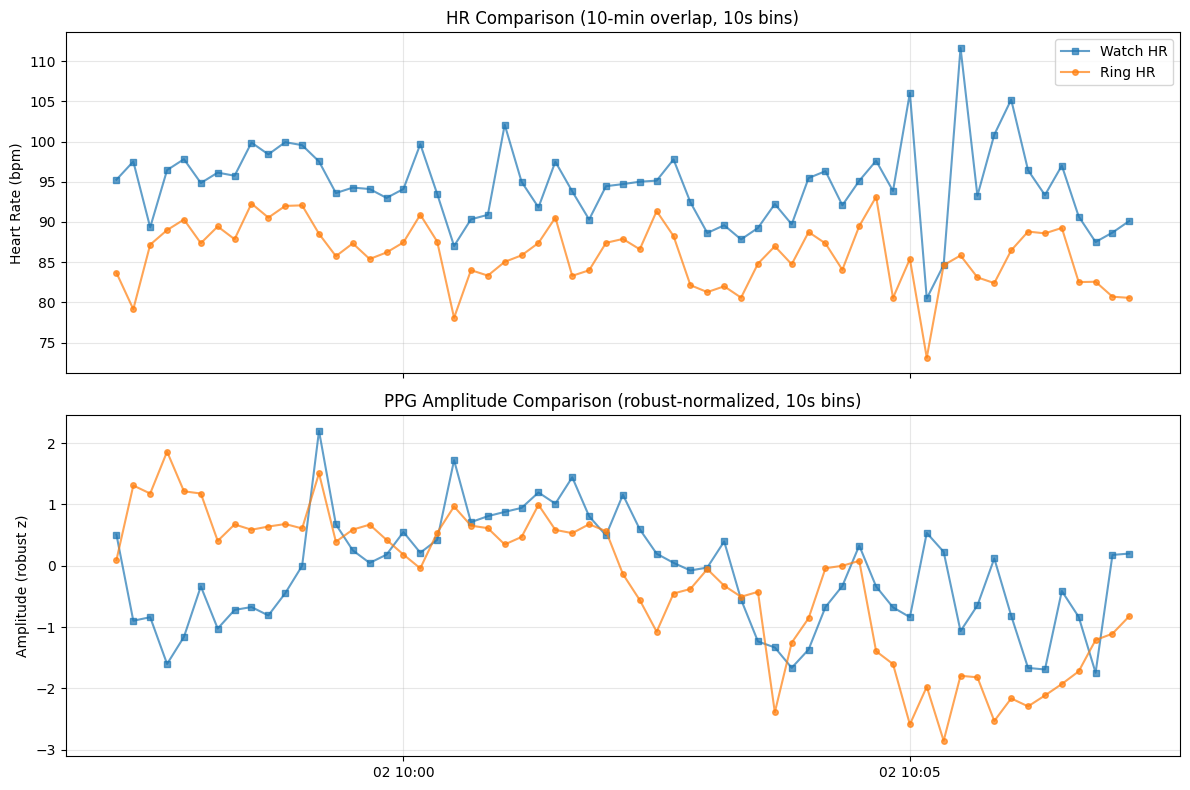

[Results saved: ppg_watch_ring_10min_results.csv]

Analysis Complete!


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks

# ============================================================
# CONFIG (Updated for 100 Hz Watch)
# ============================================================
# ✅ (수정) 100 Hz 워치 파일로 경로 변경
WATCH_CSV = "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0011/100hz/PPG100_on_demand_1767347835354.csv"
RING_CSV  = "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0011/100hz/ppgRaw.csv"

# ✅ (수정) 워치 nominal fs를 100 Hz로 변경
FS_WATCH_NOMINAL = 100.0
FS_RING_NOMINAL  = 200.0   # 참고용(타임스탬프 기반으로 실효 fs도 추정)

# Watch columns
WATCH_TIME_COL = "TIMESTAMP"   # epoch ms (또는 us/ns일 수도 있음: build_datetime_from_numeric가 자동 추정)
WATCH_PPG_COL  = "GREEN"       # GREEN / IR / RED 중 선택

# Ring columns (ppgRaw.csv는 보통 header 없음 -> 0: time, 1: ppg)
RING_TIME_COL_CANDIDATES = ["time", "Time", "timestamp", "Timestamp", "t", "index", "Index", 0]
RING_PPG_COL_CANDIDATE = 1      # 2열 파일 기준

# Beat / Filter params
MIN_BPM = 40
MAX_BPM = 200

# 100 Hz 워치에서도 그대로 사용 가능(필요시 약간 조정)
PROM_SCALE_RING  = 0.20
PROM_SCALE_WATCH = 0.10

# 비교용 집계 bin
AGG_BIN_SEC = 10   # 10초 bin 평균으로 HR/AMP 비교

# 정확히 10분 구간
TARGET_MINUTES = 10


# ============================================================
# UTIL
# ============================================================
def read_csv_robust(path: str) -> pd.DataFrame:
    """CSV 읽기 - 헤더 자동 감지 (첫 행이 숫자 헤더처럼 보이면 header=None 재로드)"""
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except:
            return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def pick_time_col(df: pd.DataFrame, candidates) -> str:
    """시간 컬럼 선택(문자열 또는 인덱스 가능)"""
    for c in candidates:
        if isinstance(c, int):
            if c < df.shape[1]:
                return df.columns[c]
        else:
            if c in df.columns:
                return c
    return df.columns[0]

def preprocess_ppg(x: np.ndarray, fs: float) -> np.ndarray:
    """detrend + bandpass (짧은 신호 예외처리 포함)"""
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(x) < 50:
        return x - np.mean(x)

    try:
        x0 = detrend(x)

        nyq = 0.5 * fs
        lo = max((MIN_BPM/60.0) / nyq, 1e-6)
        hi = min((MAX_BPM/60.0) / nyq, 0.999)
        b, a = butter(2 if fs < 50 else 4, [lo, hi], btype="band")

        default_padlen = 3 * max(len(b), len(a))
        if len(x0) <= default_padlen:
            if len(x0) <= 2 * len(b):
                return x0
            padlen = min(default_padlen, len(x0) - 1)
            return filtfilt(b, a, x0, padlen=padlen)

        return filtfilt(b, a, x0)

    except Exception:
        return x - np.mean(x)

def extract_beat_features(dt: pd.Series, ppg: np.ndarray, fs: float,
                          prom_scale: float, max_bpm_detect: float = 200.0) -> pd.DataFrame:
    """
    Peak-to-peak 기반 HR/AMP 추출
    - max_bpm_detect: 검출 단계에서 허용할 최대 bpm (Ring은 120~140 권장)
    """
    y = preprocess_ppg(ppg, fs)

    # 최소 피크 간격(=최대 bpm 기준)
    min_dist = int(round((60.0 / max_bpm_detect) * fs))
    base_prom = prom_scale * np.nanstd(y)

    peaks, prop = find_peaks(y, distance=max(1, min_dist), prominence=base_prom)
    peaks = np.sort(peaks)

    if len(peaks) < 2:
        return pd.DataFrame(columns=["dt", "HR", "AMP"])

    if not isinstance(dt, pd.Series):
        dt = pd.Series(dt)
    dt = pd.to_datetime(dt, errors="coerce")

    ibi = np.diff(peaks) / fs
    hr = 60.0 / ibi

    amp = []
    win = int(round(0.7 * fs))
    for p in peaks[1:]:
        lo = max(0, p - win)
        base = np.min(y[lo:p+1])
        amp.append(y[p] - base)

    out = pd.DataFrame({
        "dt": dt.iloc[peaks[1:]].to_numpy(),
        "HR": hr,
        "AMP": np.asarray(amp, float),
    })

    out = out[(out["HR"] >= MIN_BPM) & (out["HR"] <= MAX_BPM)]
    return out

def build_datetime_from_numeric(ts: np.ndarray, fs_hint: float, start_time: str = None) -> pd.Series:
    """
    숫자 타임스탬프 처리:
    1) epoch로 보이면 unit 추정 후 pd.to_datetime(ts, unit=...)
    2) 아니면 상대시간으로 보고 (ts-ts0) 변환 후 start_time에 더함
    """
    ts = np.asarray(ts, dtype=float)
    ts_valid = ts[np.isfinite(ts)]
    if len(ts_valid) < 10:
        raise ValueError("유효 timestamp가 너무 적습니다.")

    median_val = np.median(ts_valid)

    # ---- Heuristic: epoch detection ----
    if median_val > 1e11:
        if median_val < 1e14:
            return pd.to_datetime(ts, unit="ms", errors="coerce")
        elif median_val < 1e17:
            return pd.to_datetime(ts, unit="us", errors="coerce")
        else:
            return pd.to_datetime(ts, unit="ns", errors="coerce")

    # ---- Relative timestamp branch ----
    diffs = np.diff(ts_valid[:min(2000, len(ts_valid))])
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        raise ValueError("timestamp diffs가 유효하지 않습니다.")

    median_diff = np.median(diffs)
    expected = 1.0 / fs_hint

    unit, divisor = "s", 1.0
    if abs(median_diff - expected * 1e9) < expected * 1e9 * 0.5:
        unit, divisor = "ns", 1e9
    elif abs(median_diff - expected * 1e6) < expected * 1e6 * 0.5:
        unit, divisor = "us", 1e6
    elif abs(median_diff - expected * 1e3) < expected * 1e3 * 0.5:
        unit, divisor = "ms", 1e3
    elif abs(median_diff - expected) < expected * 0.5:
        unit, divisor = "s", 1.0
    else:
        if median_diff > 1e6:
            unit, divisor = "ns", 1e9
        elif median_diff > 1000:
            unit, divisor = "us", 1e6
        elif median_diff > 1:
            unit, divisor = "ms", 1e3
        else:
            unit, divisor = "s", 1.0

    t_seconds = (ts - ts[0]) / divisor
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    if start_time is None:
        raise ValueError("상대 timestamp에는 start_time이 필요합니다.")

    dt0 = pd.to_datetime(start_time)
    return dt0 + pd.to_timedelta(t_seconds, unit="s")

def estimate_fs_from_dt(dt) -> float:
    """datetime에서 실효 fs 추정(중앙값 간격 기반)"""
    dt = pd.Series(pd.to_datetime(dt, errors="coerce"))
    dt = dt.dropna()

    if len(dt) < 20:
        return np.nan

    dsec = dt.diff().dt.total_seconds().dropna()
    dsec = dsec[dsec > 0]  # 동일 timestamp(0초)은 제거

    if len(dsec) == 0:
        return np.nan

    med = np.median(dsec.to_numpy())
    if med <= 0:
        return np.nan

    return 1.0 / med

def aggregate_beats(beats: pd.DataFrame, bin_sec: int) -> pd.DataFrame:
    """박동 feature를 고정 bin 평균으로 집계"""
    if len(beats) == 0:
        return pd.DataFrame(columns=["dt_bin", "HR_mean", "AMP_mean"])

    b = beats.copy()
    b["dt"] = pd.to_datetime(b["dt"], errors="coerce")
    b = b.dropna(subset=["dt"]).sort_values("dt")
    if len(b) == 0:
        return pd.DataFrame(columns=["dt_bin", "HR_mean", "AMP_mean"])

    b = b.set_index("dt")
    agg = b.resample(f"{bin_sec}s").mean(numeric_only=True)
    agg = agg.rename(columns={"HR": "HR_mean", "AMP": "AMP_mean"}).reset_index().rename(columns={"dt": "dt_bin"})
    return agg.dropna(subset=["HR_mean", "AMP_mean"], how="all")


# ============================================================
# LOAD WATCH (epoch TIMESTAMP)
# ============================================================
watch_df = pd.read_csv(WATCH_CSV)
print(f"[Watch] shape={watch_df.shape}, columns={watch_df.columns.tolist()}")

if WATCH_TIME_COL not in watch_df.columns:
    raise ValueError(f"[Watch] time col '{WATCH_TIME_COL}' not found.")
if WATCH_PPG_COL not in watch_df.columns:
    raise ValueError(f"[Watch] ppg col '{WATCH_PPG_COL}' not found.")

dt_watch = build_datetime_from_numeric(
    pd.to_numeric(watch_df[WATCH_TIME_COL], errors="coerce").to_numpy(),
    fs_hint=FS_WATCH_NOMINAL,
    start_time=None
)
ppg_watch = pd.to_numeric(watch_df[WATCH_PPG_COL], errors="coerce").to_numpy(dtype=float)

fs_watch_eff = estimate_fs_from_dt(dt_watch)
print(f"[Watch] Time range: {dt_watch.min()} ~ {dt_watch.max()}")
print(f"[Watch] fs_eff ~ {fs_watch_eff:.2f} Hz (nominal {FS_WATCH_NOMINAL} Hz)")


# ============================================================
# LOAD RING (relative numeric timestamp + align to watch start)
# ============================================================
ring_df = read_csv_robust(RING_CSV)
ring_time_col = pick_time_col(ring_df, RING_TIME_COL_CANDIDATES)

if isinstance(RING_PPG_COL_CANDIDATE, int) and RING_PPG_COL_CANDIDATE < ring_df.shape[1]:
    ring_ppg_col = ring_df.columns[RING_PPG_COL_CANDIDATE]
else:
    ring_ppg_col = ring_df.columns[1]

print(f"[Ring] shape={ring_df.shape}, time_col={ring_time_col}, ppg_col={ring_ppg_col}")

ring_ts = pd.to_numeric(ring_df[ring_time_col], errors="coerce").to_numpy(dtype=float)

ring_start_time = str(pd.to_datetime(pd.Series(dt_watch)).dropna().iloc[0])
dt_ring = build_datetime_from_numeric(
    ring_ts,
    fs_hint=FS_RING_NOMINAL,
    start_time=ring_start_time
)

ppg_ring = pd.to_numeric(ring_df[ring_ppg_col], errors="coerce").to_numpy(dtype=float)

fs_ring_eff = estimate_fs_from_dt(dt_ring)
print(f"[Ring] Time range: {dt_ring.min()} ~ {dt_ring.max()}")
print(f"[Ring] fs_eff ~ {fs_ring_eff:.2f} Hz (nominal {FS_RING_NOMINAL} Hz)")

FS_WATCH = float(fs_watch_eff) if np.isfinite(fs_watch_eff) else FS_WATCH_NOMINAL
FS_RING  = float(fs_ring_eff)  if np.isfinite(fs_ring_eff)  else FS_RING_NOMINAL


# ============================================================
# PICK EXACT 10-MIN COMMON WINDOW
# ============================================================
start_common = max(pd.to_datetime(dt_watch.min()), pd.to_datetime(dt_ring.min()))
end_common   = min(pd.to_datetime(dt_watch.max()), pd.to_datetime(dt_ring.max()))
print(f"\n[Common Overlap] {start_common} ~ {end_common} ({(end_common-start_common).total_seconds():.1f}s)")

if (end_common - start_common).total_seconds() <= 0:
    raise ValueError("두 데이터의 시간이 겹치지 않습니다.")

target_sec = TARGET_MINUTES * 60

win_start = start_common
win_end   = start_common + pd.Timedelta(seconds=target_sec)

if win_end > end_common:
    win_end   = end_common
    win_start = end_common - pd.Timedelta(seconds=target_sec)

if (win_end - win_start).total_seconds() < target_sec:
    raise ValueError("겹치는 구간이 10분보다 짧습니다. (동시 10분 데이터인지 확인 필요)")

print(f"[Selected 10-min Window] {win_start} ~ {win_end}")

m_watch = (dt_watch >= win_start) & (dt_watch <= win_end)
m_ring  = (dt_ring  >= win_start) & (dt_ring  <= win_end)

dt_watch_10 = pd.Series(dt_watch[m_watch]).reset_index(drop=True)
ppg_watch_10 = ppg_watch[m_watch]

dt_ring_10  = pd.Series(dt_ring[m_ring]).reset_index(drop=True)
ppg_ring_10 = ppg_ring[m_ring]

watch_dur = (pd.to_datetime(dt_watch_10.iloc[-1]) - pd.to_datetime(dt_watch_10.iloc[0])).total_seconds()
ring_dur  = (pd.to_datetime(dt_ring_10.iloc[-1])  - pd.to_datetime(dt_ring_10.iloc[0])).total_seconds()

print(f"\n[10-min Cut]")
print(f"  Watch: {len(ppg_watch_10)} samples, {watch_dur:.1f}s @ {FS_WATCH:.2f}Hz")
print(f"  Ring : {len(ppg_ring_10)} samples, {ring_dur:.1f}s @ {FS_RING:.2f}Hz")


# ============================================================
# EXTRACT BEATS
# ============================================================
print("\n[Extracting beat features...]")
beats_watch = extract_beat_features(dt_watch_10, ppg_watch_10, FS_WATCH, PROM_SCALE_WATCH, max_bpm_detect=200)
beats_ring  = extract_beat_features(dt_ring_10,  ppg_ring_10,  FS_RING,  PROM_SCALE_RING,  max_bpm_detect=120)

print(f"  Watch beats: {len(beats_watch)}")
print(f"  Ring  beats: {len(beats_ring)}")

# ============================================================
# AGGREGATE & ALIGN (fixed bins)
# ============================================================
agg_watch = aggregate_beats(beats_watch, AGG_BIN_SEC).rename(columns={"HR_mean":"HR_watch","AMP_mean":"AMP_watch"})
agg_ring  = aggregate_beats(beats_ring,  AGG_BIN_SEC).rename(columns={"HR_mean":"HR_ring","AMP_mean":"AMP_ring"})

compare = pd.merge(agg_watch, agg_ring, on="dt_bin", how="inner").sort_values("dt_bin").reset_index(drop=True)
print(f"\n[Aligned bins] n={len(compare)} (bin={AGG_BIN_SEC}s)")

# ============================================================
# AMP Robust Normalization
# ============================================================
for col in ["AMP_watch", "AMP_ring"]:
    if col in compare.columns:
        m = compare[col].median()
        s = 1.4826 * (compare[col] - m).abs().median()
        compare[col + "_norm"] = (compare[col] - m) / (s + 1e-9)

# ============================================================
# CORRELATION
# ============================================================
print("\n" + "="*80)
print("[Result: Watch vs Ring Correlation on 10-min window]")
print("="*80)

def corr_pair(df, a, b):
    v = df[[a, b]].dropna()
    if len(v) < 3:
        return np.nan, len(v)
    r = np.corrcoef(v[a], v[b])[0, 1]
    return float(r), len(v)

r_hr, n_hr = corr_pair(compare, "HR_watch", "HR_ring")
r_amp, n_amp = corr_pair(compare, "AMP_watch_norm", "AMP_ring_norm")

print(f"  HR  : n={n_hr:3d}, r={r_hr:+.3f}" if np.isfinite(r_hr) else f"  HR  : Not enough data (n={n_hr})")
print(f"  AMP : n={n_amp:3d}, r={r_amp:+.3f}" if np.isfinite(r_amp) else f"  AMP : Not enough data (n={n_amp})")

# ============================================================
# VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
if "HR_watch" in compare and compare["HR_watch"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["HR_watch"], "s-", label="Watch HR", alpha=0.7, markersize=4)
if "HR_ring" in compare and compare["HR_ring"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["HR_ring"], "o-", label="Ring HR", alpha=0.7, markersize=4)
ax.set_ylabel("Heart Rate (bpm)")
ax.set_title(f"HR Comparison (10-min overlap, {AGG_BIN_SEC}s bins)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
if "AMP_watch_norm" in compare and compare["AMP_watch_norm"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["AMP_watch_norm"], "s-", label="Watch AMP (norm)", alpha=0.7, markersize=4)
if "AMP_ring_norm" in compare and compare["AMP_ring_norm"].notna().sum() > 0:
    ax.plot(compare["dt_bin"], compare["AMP_ring_norm"], "o-", label="Ring AMP (norm)", alpha=0.7, markersize=4)
ax.set_ylabel("Amplitude (robust z)")
ax.set_title(f"PPG Amplitude Comparison (robust-normalized, {AGG_BIN_SEC}s bins)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ppg_watch_ring_10min_comparison.png", dpi=150, bbox_inches="tight")
print("\n[Plot saved: ppg_watch_ring_10min_comparison.png]")
plt.show()

# ============================================================
# SAVE
# ============================================================
compare.to_csv("ppg_watch_ring_10min_results.csv", index=False)
print("[Results saved: ppg_watch_ring_10min_results.csv]")
print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

# ============================================================
# Watch (100Hz) vs Ring (ppgRaw): 5-min HRV + nNN filtering + RR errors + RMSSD Bland-Altman
#   - Watch: TIMESTAMP(epoch ms/us/ns) + GREEN/IR/RED
#   - Ring : ppgRaw.csv (header 없을 수 있음, time 상대/epoch 모두 대응)
# ============================================================

CFG = {
    # [FILES]  ✅ 100Hz Watch / Ring 파일로 변경
    "FILE_WATCH": "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0011/100hz/PPG100_on_demand_1767347835354.csv",
    "FILE_RING":  "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0011/25hz/ppgRaw.csv",

    # [ANALYSIS RANGE] (원하시는 구간)
    "START": "2026-01-02 09:57:15.635",
    "END":   "2026-01-02 10:07:15.635",

    # [WATCH COLUMNS] ✅ 100Hz 워치 포맷
    "WATCH_TIME_COL": "TIMESTAMP",   # epoch (ms/us/ns 자동 추정)
    "WATCH_PPG_COL":  "GREEN",       # GREEN / IR / RED 중 선택
    "SPO2_COL_WATCH": None,          # 없으면 None

    # [RING COLUMNS] ✅ ppgRaw.csv 대응
    "READ_RING_HEADER_NONE": True,   # ppgRaw.csv가 header 없으면 True
    "RING_TIME_COL_CANDIDATES": ["time","Time","timestamp","Timestamp","t","index","Index",0],
    "RING_PPG_COL_CANDIDATE": 1,     # 2열 파일 기준 (0:time, 1:ppg)
    "SPO2_COL_RING": None,

    # [SAMPLING RATES] (참고용: peak time은 실제 timestamp로 계산)
    "FS_WATCH_NOMINAL": 100.0,
    "FS_RING_NOMINAL":  200.0,

    # [WINDOW] ★ HRV는 5분 권장
    "WIN_SEC": 300,     # 5 minutes
    "STEP_SEC": 60,     # 1 minute step

    # [QC]
    "MIN_VALID_RATIO_WATCH": 0.70,
    "MIN_VALID_RATIO_RING": 0.90,
    "MIN_SNR_DB": -10.0,

    # [Physiology]
    "HR_MIN": 40,
    "HR_MAX": 180,
    "RR_MIN_MS": 300,
    "RR_MAX_MS": 1500,
    "RR_DEV_FROM_MED_FRAC": 0.20,   # median 대비 20% 이상 벗어나면 제외

    # [HRV reliability]
    "MIN_NN_FOR_RMSSD": 30,          # ★ nNN < 30이면 RMSSD 제외

    # [RR matching & error]
    "PEAK_MATCH_TOL_MS": 150,        # Watch peak vs Ring peak 매칭 허용 오차
    "RR_OUTLIER_MS": 50,             # RR error outlier 정의: |err| > 50ms

    # [Bootstrap CI for RMSSD]
    "RMSSD_BOOTSTRAP": True,
    "RMSSD_BOOT_N": 300,
    "RMSSD_BOOT_MIN_DIFF": 20,

    # [OUTPUT]
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_hrv_watch_ring_100hz",
    "RUN_ID": "hrv_5min_rrerr_rmssdBA_100hz",
}
os.makedirs(CFG["OUT_DIR"], exist_ok=True)


# ============================================================
# Helpers
# ============================================================
def robust_mad(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med)) + 1e-12

def bandpass_filter(data, fs, lowcut=0.5, highcut=5.0, order=2):
    data = np.asarray(data, float)
    if np.isfinite(data).sum() < max(int(fs * 2), 10):
        return data
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    try:
        fill = np.nanmedian(data[np.isfinite(data)]) if np.any(np.isfinite(data)) else 0.0
        return filtfilt(b, a, np.nan_to_num(data, nan=fill))
    except Exception:
        return data

def calc_snr(x, fs):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < fs * 2:
        return np.nan
    x = x - np.mean(x)
    n = len(x)
    freq = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(np.fft.rfft(x * np.hanning(n)))**2

    sig_mask = (freq >= 0.5) & (freq <= 4.0)
    noise_mask = ((freq >= 0.1) & (freq < 0.5)) | ((freq > 4.0) & (freq <= 10.0))

    s_power = np.sum(mag[sig_mask])
    n_power = np.sum(mag[noise_mask])
    if n_power <= 0:
        return 50.0
    return 10 * np.log10(s_power / n_power)

def read_csv_robust(path: str) -> pd.DataFrame:
    """CSV 읽기 - 헤더 자동 감지 (첫 행이 숫자 헤더처럼 보이면 header=None 재로드)"""
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except:
            return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def pick_time_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if isinstance(c, int):
            if c < df.shape[1]:
                return df.columns[c]
        else:
            if c in df.columns:
                return c
    return df.columns[0]

def build_datetime_from_numeric(ts: np.ndarray, fs_hint: float, start_time: str = None) -> pd.Series:
    """
    숫자 타임스탬프 처리:
    1) epoch로 보이면 unit 추정 후 pd.to_datetime(ts, unit=...)
    2) 아니면 상대시간으로 보고 (ts-ts0) 변환 후 start_time에 더함
    """
    ts = np.asarray(ts, dtype=float)
    ts_valid = ts[np.isfinite(ts)]
    if len(ts_valid) < 10:
        raise ValueError("유효 timestamp가 너무 적습니다.")

    median_val = np.median(ts_valid)

    # epoch detection: ms ~ 1e12~1e13, us ~ 1e15, ns ~ 1e18
    if median_val > 1e11:
        if median_val < 1e14:
            return pd.to_datetime(ts, unit="ms", errors="coerce")
        elif median_val < 1e17:
            return pd.to_datetime(ts, unit="us", errors="coerce")
        else:
            return pd.to_datetime(ts, unit="ns", errors="coerce")

    # relative timestamp branch
    diffs = np.diff(ts_valid[:min(2000, len(ts_valid))])
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        raise ValueError("timestamp diffs가 유효하지 않습니다.")

    median_diff = np.median(diffs)
    expected = 1.0 / fs_hint

    unit, divisor = "s", 1.0
    if abs(median_diff - expected * 1e9) < expected * 1e9 * 0.5:
        unit, divisor = "ns", 1e9
    elif abs(median_diff - expected * 1e6) < expected * 1e6 * 0.5:
        unit, divisor = "us", 1e6
    elif abs(median_diff - expected * 1e3) < expected * 1e3 * 0.5:
        unit, divisor = "ms", 1e3
    elif abs(median_diff - expected) < expected * 0.5:
        unit, divisor = "s", 1.0
    else:
        if median_diff > 1e6:
            unit, divisor = "ns", 1e9
        elif median_diff > 1000:
            unit, divisor = "us", 1e6
        elif median_diff > 1:
            unit, divisor = "ms", 1e3
        else:
            unit, divisor = "s", 1.0

    t_seconds = (ts - ts[0]) / divisor
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    if start_time is None:
        raise ValueError("상대 timestamp에는 start_time이 필요합니다.")

    dt0 = pd.to_datetime(start_time)
    return dt0 + pd.to_timedelta(t_seconds, unit="s")

def detect_peaks_keep_index(sig, fs):
    """
    NaN을 제거하지 않고(인덱스 보존), 보간/대체 후 필터링-피크검출
    return: peaks_idx (원 신호 인덱스), filt_sig
    """
    sig = np.asarray(sig, float)
    if len(sig) < int(fs * 8):
        return np.array([], dtype=int), sig

    if np.any(~np.isfinite(sig)):
        s = pd.Series(sig).interpolate(limit_direction="both").to_numpy(dtype=float)
    else:
        s = sig.copy()

    x = bandpass_filter(s, fs)
    x = x - np.median(x)

    scale = robust_mad(x)
    if not np.isfinite(scale) or scale <= 0:
        return np.array([], dtype=int), x

    min_dist = int(fs * (60.0 / max(CFG["HR_MAX"], 1)))
    min_dist = max(min_dist, 1)
    prom = 0.8 * scale

    p, _ = find_peaks(x, distance=min_dist, prominence=prom)
    return p.astype(int), x

def compute_nn_metrics_from_peak_times(peak_times_sec):
    """
    peak_times_sec: window 시작 기준 peak time(초) 배열
    returns:
      hr_bpm (median RR), rmssd_ms (if nNN>=MIN_NN_FOR_RMSSD else NaN),
      nn_ms, rr_removed_ratio, counts dict, rmssd_ci_low/high
    """
    peak_times_sec = np.asarray(peak_times_sec, float)
    peak_times_sec = peak_times_sec[np.isfinite(peak_times_sec)]
    peak_times_sec = np.sort(peak_times_sec)

    if len(peak_times_sec) < 4:
        return np.nan, np.nan, np.array([]), np.nan, {"n_peaks": int(len(peak_times_sec)), "n_rr_raw": 0, "n_nn": 0}, (np.nan, np.nan)

    rr_ms_raw = np.diff(peak_times_sec) * 1000.0
    n_rr_raw = len(rr_ms_raw)

    # 1) physiological bounds
    m1 = (rr_ms_raw >= CFG["RR_MIN_MS"]) & (rr_ms_raw <= CFG["RR_MAX_MS"])
    rr_ms_1 = rr_ms_raw[m1]

    # 2) median deviation
    if len(rr_ms_1) >= 3:
        med = np.median(rr_ms_1)
        m2 = np.abs(rr_ms_1 - med) <= (CFG["RR_DEV_FROM_MED_FRAC"] * med)
        nn = rr_ms_1[m2]
    else:
        nn = np.array([])

    n_nn = len(nn)
    rr_removed_ratio = 1.0 - (n_nn / max(n_rr_raw, 1))

    hr = np.nan
    rmssd = np.nan
    ci_lo, ci_hi = np.nan, np.nan

    if n_nn >= 3:
        hr = 60000.0 / np.median(nn)

    if n_nn >= CFG["MIN_NN_FOR_RMSSD"]:
        diff_nn = np.diff(nn)
        if len(diff_nn) > 0:
            rmssd = float(np.sqrt(np.mean(diff_nn**2)))

            if CFG["RMSSD_BOOTSTRAP"] and (len(diff_nn) >= CFG["RMSSD_BOOT_MIN_DIFF"]):
                B = int(CFG["RMSSD_BOOT_N"])
                boot = np.empty(B, float)
                for b in range(B):
                    samp = np.random.choice(diff_nn, size=len(diff_nn), replace=True)
                    boot[b] = np.sqrt(np.mean(samp**2))
                ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    counts = {"n_peaks": int(len(peak_times_sec)), "n_rr_raw": int(n_rr_raw), "n_nn": int(n_nn)}
    return float(hr), rmssd, nn, float(rr_removed_ratio), counts, (float(ci_lo), float(ci_hi))

def match_peaks_by_time(tA, tB, tol_ms):
    """
    tA, tB: peak times in seconds (sorted)
    returns matched indices in A and B (same length)
    greedy two-pointer matching
    """
    tA = np.asarray(tA, float); tB = np.asarray(tB, float)
    tol = tol_ms / 1000.0
    i = j = 0
    mA, mB = [], []
    while i < len(tA) and j < len(tB):
        dt = tA[i] - tB[j]
        if abs(dt) <= tol:
            mA.append(i); mB.append(j)
            i += 1; j += 1
        else:
            if tA[i] < tB[j]:
                i += 1
            else:
                j += 1
    return np.array(mA, int), np.array(mB, int)

def load_watch_100hz_format(csv_path):
    """✅ Watch 100Hz 포맷 로드 (TIMESTAMP + GREEN/IR/RED)"""
    df = pd.read_csv(csv_path)
    print(f"[Watch] shape={df.shape}, columns={df.columns.tolist()}")

    if CFG["WATCH_TIME_COL"] not in df.columns:
        raise ValueError(f"[Watch] '{CFG['WATCH_TIME_COL']}' 컬럼이 없습니다.")
    if CFG["WATCH_PPG_COL"] not in df.columns:
        raise ValueError(f"[Watch] '{CFG['WATCH_PPG_COL']}' 컬럼이 없습니다.")

    ts = pd.to_numeric(df[CFG["WATCH_TIME_COL"]], errors="coerce").to_numpy(dtype=float)
    dt = build_datetime_from_numeric(ts, fs_hint=CFG["FS_WATCH_NOMINAL"], start_time=None)

    ppg = pd.to_numeric(df[CFG["WATCH_PPG_COL"]], errors="coerce").to_numpy(dtype=float)

    spo2 = np.full(len(df), np.nan)
    if CFG["SPO2_COL_WATCH"] and CFG["SPO2_COL_WATCH"] in df.columns:
        spo2 = pd.to_numeric(df[CFG["SPO2_COL_WATCH"]], errors="coerce").to_numpy()

    return pd.to_datetime(dt, errors="coerce"), ppg, spo2

def load_ring_ppgraw(csv_path, start_time):
    """✅ Ring ppgRaw 로드: 상대/epoch timestamp 모두 자동 처리 후 start_time에 정렬"""
    df = read_csv_robust(csv_path)
    time_col = pick_time_col(df, CFG["RING_TIME_COL_CANDIDATES"])

    if isinstance(CFG["RING_PPG_COL_CANDIDATE"], int) and CFG["RING_PPG_COL_CANDIDATE"] < df.shape[1]:
        ppg_col = df.columns[CFG["RING_PPG_COL_CANDIDATE"]]
    else:
        ppg_col = df.columns[1]

    print(f"[Ring] shape={df.shape}, time_col={time_col}, ppg_col={ppg_col}")

    ts = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)

    # 상대 timestamp일 확률이 높으므로 start_time에 붙여 build
    dt = build_datetime_from_numeric(ts, fs_hint=CFG["FS_RING_NOMINAL"], start_time=str(pd.to_datetime(start_time)))

    ppg = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)

    spo2 = np.full(len(df), np.nan)
    if CFG["SPO2_COL_RING"] is not None and df.shape[1] > CFG["SPO2_COL_RING"]:
        spo2 = pd.to_numeric(df[df.columns[CFG["SPO2_COL_RING"]]], errors="coerce").to_numpy()

    return pd.to_datetime(dt, errors="coerce"), ppg, spo2


# ============================================================
# Load data
# ============================================================
print("="*80)
print("🫀 HRV Analysis: Watch (100Hz) vs Ring (ppgRaw)")
print("   5-min windows + nNN filtering + RR errors + RMSSD Bland-Altman")
print("="*80)

t0 = pd.to_datetime(CFG["START"])
t1 = pd.to_datetime(CFG["END"])

print(f"\n📅 Analysis Range:")
print(f"   {t0} ~ {t1}")
print(f"   Duration: {(t1-t0).total_seconds()/60:.2f} minutes")

# Load Watch (100Hz format)
print(f"\n📂 Loading Watch (100Hz format)...")
dt_watch_full, x_watch_full, s_watch_full = load_watch_100hz_format(CFG["FILE_WATCH"])
print(f"   Time range: {dt_watch_full.min()} ~ {dt_watch_full.max()}")

# Load Ring (ppgRaw)
print(f"\n📂 Loading Ring (ppgRaw)...")
# 링 start_time은 분석 시작(t0) 또는 워치 시작으로 두는 것이 일반적
dt_ring_full, x_ring_full, s_ring_full = load_ring_ppgraw(CFG["FILE_RING"], start_time=t0)
print(f"   Time range: {dt_ring_full.min()} ~ {dt_ring_full.max()}")

# Cut to analysis range
m_watch = (dt_watch_full >= t0) & (dt_watch_full <= t1)
m_ring  = (dt_ring_full  >= t0) & (dt_ring_full  <= t1)

dt_watch = pd.to_datetime(dt_watch_full[m_watch]).to_numpy()
x_watch  = x_watch_full[m_watch]
s_watch  = s_watch_full[m_watch]

dt_ring = pd.to_datetime(dt_ring_full[m_ring]).to_numpy()
x_ring   = x_ring_full[m_ring]
s_ring   = s_ring_full[m_ring]

# Convert to float seconds timestamps (sub-second precision)
ts_watch = (pd.to_datetime(dt_watch).astype("datetime64[ns]").astype(np.int64) / 1e9).astype(np.float64)
ts_ring  = (pd.to_datetime(dt_ring).astype("datetime64[ns]").astype(np.int64) / 1e9).astype(np.float64)

print(f"\n📊 Samples in range:")
print(f"   Watch: {len(ts_watch):,}")
print(f"   Ring:  {len(ts_ring):,}")

# ============================================================
# Window loop (5-min)
# ============================================================
win_sec  = float(CFG["WIN_SEC"])
step_sec = float(CFG["STEP_SEC"])
start_ts = float(t0.timestamp())
end_ts   = float(t1.timestamp())

rows = []
rr_err_rows = []  # beat-to-beat RR error samples

cur = start_ts
wid = 0
print(f"\n🔄 Analyzing windows: win={win_sec}s, step={step_sec}s")

while cur + win_sec <= end_ts:
    w0, w1 = cur, cur + win_sec

    w_watch = (ts_watch >= w0) & (ts_watch < w1)
    w_ring  = (ts_ring  >= w0) & (ts_ring  < w1)

    sig_watch = x_watch[w_watch]
    sig_ring  = x_ring[w_ring]
    sp_watch  = s_watch[w_watch]
    sp_ring   = s_ring[w_ring]

    ts_watch_w = ts_watch[w_watch]
    ts_ring_w  = ts_ring[w_ring]

    # (참고) 기대 샘플 수 기준 coverage
    exp_watch = CFG["FS_WATCH_NOMINAL"] * win_sec
    exp_ring  = CFG["FS_RING_NOMINAL"]  * win_sec
    cov_watch = (np.isfinite(sig_watch).sum() / exp_watch) if exp_watch > 0 else np.nan
    cov_ring  = (np.isfinite(sig_ring).sum()  / exp_ring)  if exp_ring  > 0 else np.nan

    valid_watch = np.isfinite(sig_watch).mean() if len(sig_watch) else 0.0
    valid_ring  = np.isfinite(sig_ring).mean()  if len(sig_ring)  else 0.0

    res = {
        "window_id": wid,
        "time": pd.to_datetime(w0, unit="s"),

        "cov_watch": float(cov_watch),
        "cov_ring": float(cov_ring),
        "valid_watch": float(valid_watch),
        "valid_ring": float(valid_ring),

        "snr_watch": calc_snr(sig_watch, CFG["FS_WATCH_NOMINAL"]) if np.isfinite(sig_watch).sum() > 0 else np.nan,
        "snr_ring":  calc_snr(sig_ring,  CFG["FS_RING_NOMINAL"])  if np.isfinite(sig_ring).sum()  > 0 else np.nan,

        # HR/HRV
        "hr_watch": np.nan, "rmssd_watch": np.nan,
        "hr_ring": np.nan,  "rmssd_ring": np.nan,

        # nNN + removal ratio
        "nPk_watch": np.nan, "nRR_watch": np.nan, "nNN_watch": np.nan, "rr_removed_watch": np.nan,
        "nPk_ring": np.nan,  "nRR_ring": np.nan,  "nNN_ring": np.nan,  "rr_removed_ring": np.nan,

        # RMSSD CI
        "rmssd_watch_ci_lo": np.nan, "rmssd_watch_ci_hi": np.nan,
        "rmssd_ring_ci_lo": np.nan,  "rmssd_ring_ci_hi": np.nan,

        # RR(IBI) error stats (ms)
        "rr_mae_ms": np.nan,
        "rr_median_err_ms": np.nan,
        "rr_outlier_rate": np.nan,
        "nMatchPeaks": np.nan,

        # SpO2 mean (없으면 NaN)
        "spo2_watch": np.nanmean(sp_watch) if np.isfinite(sp_watch).sum() > 0 else np.nan,
        "spo2_ring":  np.nanmean(sp_ring)  if np.isfinite(sp_ring).sum()  > 0 else np.nan,
    }

    # ---- Peak detection (index preserved)
    peaks_watch_idx, _ = detect_peaks_keep_index(sig_watch, CFG["FS_WATCH_NOMINAL"])
    peaks_ring_idx,  _ = detect_peaks_keep_index(sig_ring,  CFG["FS_RING_NOMINAL"])

    # ---- Peak times (✅ 실제 timestamp 기반: 링 실효 fs가 달라도 OK)
    # window 안에서 ts가 비어있거나 peaks가 범위를 넘는 경우 방어
    t_watch_peaks = np.array([], float)
    t_ring_peaks  = np.array([], float)

    if len(ts_watch_w) > 0 and len(peaks_watch_idx) > 0:
        peaks_watch_idx = peaks_watch_idx[peaks_watch_idx < len(ts_watch_w)]
        t_watch_peaks = ts_watch_w[peaks_watch_idx] - ts_watch_w[0]

    if len(ts_ring_w) > 0 and len(peaks_ring_idx) > 0:
        peaks_ring_idx = peaks_ring_idx[peaks_ring_idx < len(ts_ring_w)]
        t_ring_peaks = ts_ring_w[peaks_ring_idx] - ts_ring_w[0]

    # ---- Watch metrics
    hr_w, rmssd_w, nn_w, rem_w, c_w, ci_w = compute_nn_metrics_from_peak_times(t_watch_peaks)
    res["nPk_watch"], res["nRR_watch"], res["nNN_watch"], res["rr_removed_watch"] = c_w["n_peaks"], c_w["n_rr_raw"], c_w["n_nn"], rem_w
    res["rmssd_watch_ci_lo"], res["rmssd_watch_ci_hi"] = ci_w

    if np.isfinite(hr_w) and (CFG["HR_MIN"] <= hr_w <= CFG["HR_MAX"]):
        if (valid_watch >= CFG["MIN_VALID_RATIO_WATCH"]) and (cov_watch >= CFG["MIN_VALID_RATIO_WATCH"]):
            res["hr_watch"] = hr_w
            res["rmssd_watch"] = rmssd_w

    # ---- Ring metrics
    hr_r, rmssd_r, nn_r, rem_r, c_r, ci_r = compute_nn_metrics_from_peak_times(t_ring_peaks)
    res["nPk_ring"], res["nRR_ring"], res["nNN_ring"], res["rr_removed_ring"] = c_r["n_peaks"], c_r["n_rr_raw"], c_r["n_nn"], rem_r
    res["rmssd_ring_ci_lo"], res["rmssd_ring_ci_hi"] = ci_r

    if np.isfinite(hr_r) and (CFG["HR_MIN"] <= hr_r <= CFG["HR_MAX"]):
        if (valid_ring >= CFG["MIN_VALID_RATIO_RING"]) and (cov_ring >= CFG["MIN_VALID_RATIO_RING"]):
            res["hr_ring"] = hr_r
            res["rmssd_ring"] = rmssd_r

    # ---- RR(IBI) error: peak time matching
    if len(t_watch_peaks) >= 4 and len(t_ring_peaks) >= 4:
        mA, mB = match_peaks_by_time(t_watch_peaks, t_ring_peaks, CFG["PEAK_MATCH_TOL_MS"])
        res["nMatchPeaks"] = int(len(mA))

        if len(mA) >= 4:
            t_watch_m = t_watch_peaks[mA]
            t_ring_m  = t_ring_peaks[mB]

            rr_watch_m = np.diff(t_watch_m) * 1000.0
            rr_ring_m  = np.diff(t_ring_m)  * 1000.0

            mm = (
                (rr_watch_m >= CFG["RR_MIN_MS"]) & (rr_watch_m <= CFG["RR_MAX_MS"]) &
                (rr_ring_m  >= CFG["RR_MIN_MS"]) & (rr_ring_m  <= CFG["RR_MAX_MS"])
            )
            rr_watch_m = rr_watch_m[mm]
            rr_ring_m  = rr_ring_m[mm]

            if len(rr_watch_m) >= 3:
                err = rr_watch_m - rr_ring_m
                res["rr_mae_ms"] = float(np.mean(np.abs(err)))
                res["rr_median_err_ms"] = float(np.median(err))
                res["rr_outlier_rate"] = float(np.mean(np.abs(err) > CFG["RR_OUTLIER_MS"]))

                for e in err:
                    rr_err_rows.append({
                        "window_id": wid,
                        "time": res["time"],
                        "rr_err_ms": float(e),
                    })

    rows.append(res)
    cur += step_sec
    wid += 1

res_df = pd.DataFrame(rows)
rr_err_df = pd.DataFrame(rr_err_rows)

print(f"\n✅ Analyzed {len(res_df)} windows")

# ============================================================
# Save CSV
# ============================================================
out_full = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
res_df.to_csv(out_full, index=False)

out_rrerr = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rr_errors.csv")
rr_err_df.to_csv(out_rrerr, index=False)

print(f"💾 Saved: {out_full}")
print(f"💾 Saved: {out_rrerr}")

# ============================================================
# Summary Statistics
# ============================================================
valid_hr = res_df.dropna(subset=["hr_watch", "hr_ring"]).copy()
valid_rmssd = res_df.dropna(subset=["rmssd_watch", "rmssd_ring"]).copy()
valid_rrerr = res_df.dropna(subset=["rr_mae_ms"]).copy()

print("\n" + "="*80)
print("📊 SUMMARY STATISTICS")
print("="*80)
print(f"\nTotal windows: {len(res_df)}")
print(f"Valid HR pairs: {len(valid_hr)}")
print(f"Valid RMSSD pairs (nNN≥30): {len(valid_rmssd)}")
print(f"Valid RR error windows: {len(valid_rrerr)}")

print(f"\n[Coverage] (nominal fs 기준)")
print(f"  Watch: mean={res_df['cov_watch'].mean():.3f}, median={res_df['cov_watch'].median():.3f}")
print(f"  Ring:  mean={res_df['cov_ring'].mean():.3f}, median={res_df['cov_ring'].median():.3f}")

print(f"\n[SNR (dB)]")
print(f"  Watch: mean={res_df['snr_watch'].mean():.2f}, std={res_df['snr_watch'].std():.2f}")
print(f"  Ring:  mean={res_df['snr_ring'].mean():.2f}, std={res_df['snr_ring'].std():.2f}")

print(f"\n[nNN & removal]")
print(f"  Watch nNN: median={np.nanmedian(res_df['nNN_watch']):.1f}, removal={np.nanmedian(res_df['rr_removed_watch']):.3f}")
print(f"  Ring nNN:  median={np.nanmedian(res_df['nNN_ring']):.1f}, removal={np.nanmedian(res_df['rr_removed_ring']):.3f}")

if len(valid_hr) > 0:
    dhr = valid_hr["hr_watch"] - valid_hr["hr_ring"]
    corr_hr = valid_hr["hr_watch"].corr(valid_hr["hr_ring"])
    print(f"\n[HR Agreement]")
    print(f"  Correlation: {corr_hr:.3f}")
    print(f"  Mean(Watch-Ring): {dhr.mean():.3f} bpm")
    print(f"  Std: {dhr.std():.3f} bpm")
    print(f"  MAE: {np.mean(np.abs(dhr)):.3f} bpm")

if len(valid_rrerr) > 0:
    print(f"\n[RR(IBI) Error]")
    print(f"  MAE: median={np.nanmedian(res_df['rr_mae_ms']):.2f} ms, mean={np.nanmean(res_df['rr_mae_ms']):.2f} ms")
    print(f"  Median error: {np.nanmedian(res_df['rr_median_err_ms']):.2f} ms")
    print(f"  Outlier rate(|err|>{CFG['RR_OUTLIER_MS']}ms): {np.nanmean(res_df['rr_outlier_rate']):.3f}")

if len(valid_rmssd) > 0:
    drmssd = valid_rmssd["rmssd_watch"] - valid_rmssd["rmssd_ring"]
    corr_rmssd = valid_rmssd["rmssd_watch"].corr(valid_rmssd["rmssd_ring"])
    print(f"\n[RMSSD Agreement]")
    print(f"  Correlation: {corr_rmssd:.3f}")
    print(f"  Mean(Watch-Ring): {drmssd.mean():.3f} ms")
    print(f"  Std: {drmssd.std():.3f} ms")
    print(f"  MAE: {np.mean(np.abs(drmssd)):.3f} ms")

# Save summary to text file
summary_txt = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_summary.txt")
with open(summary_txt, "w", encoding="utf-8") as f:
    f.write("===== HRV Analysis Summary =====\n\n")
    f.write(f"Total windows: {len(res_df)}\n")
    f.write(f"Valid HR pairs: {len(valid_hr)}\n")
    f.write(f"Valid RMSSD pairs: {len(valid_rmssd)}\n")
    f.write(f"Valid RR error windows: {len(valid_rrerr)}\n\n")

    f.write("[Coverage] (nominal fs 기준)\n")
    f.write(f"  Watch: {res_df['cov_watch'].mean():.3f}\n")
    f.write(f"  Ring:  {res_df['cov_ring'].mean():.3f}\n\n")

    if len(valid_hr) > 0:
        f.write("[HR Agreement]\n")
        f.write(f"  Corr: {corr_hr:.3f}\n")
        f.write(f"  Mean diff: {dhr.mean():.3f} bpm\n")
        f.write(f"  MAE: {np.mean(np.abs(dhr)):.3f} bpm\n\n")

    if len(valid_rmssd) > 0:
        f.write("[RMSSD Agreement]\n")
        f.write(f"  Corr: {corr_rmssd:.3f}\n")
        f.write(f"  Mean diff: {drmssd.mean():.3f} ms\n")
        f.write(f"  MAE: {np.mean(np.abs(drmssd)):.3f} ms\n\n")

print(f"📝 Saved: {summary_txt}")

# ============================================================
# Visualization
# ============================================================
print(f"\n📈 Creating plots...")

# 1. HR Correlation
if len(valid_hr) > 0:
    fig = plt.figure(figsize=(6, 5))
    plt.scatter(valid_hr["hr_ring"], valid_hr["hr_watch"], s=20, alpha=0.6)
    lo, hi = CFG["HR_MIN"], CFG["HR_MAX"]
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=2)
    plt.title(f"HR Agreement\nCorr={corr_hr:.3f}", fontsize=14, fontweight='bold')
    plt.xlabel("Ring HR (bpm)", fontsize=12)
    plt.ylabel("Watch HR (bpm)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_hr_corr.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

# 2. RMSSD Correlation
if len(valid_rmssd) > 0:
    fig = plt.figure(figsize=(6, 5))
    plt.scatter(valid_rmssd["rmssd_ring"], valid_rmssd["rmssd_watch"], s=20, alpha=0.6)
    mx = np.nanmax([valid_rmssd["rmssd_ring"].max(), valid_rmssd["rmssd_watch"].max()])
    plt.plot([0, mx], [0, mx], "r--", linewidth=2)
    plt.title(f"RMSSD Agreement\nCorr={corr_rmssd:.3f}", fontsize=14, fontweight='bold')
    plt.xlabel("Ring RMSSD (ms)", fontsize=12)
    plt.ylabel("Watch RMSSD (ms)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rmssd_corr.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

# 3. RR Error Distribution
if len(rr_err_df) > 0:
    fig = plt.figure(figsize=(7, 5))
    plt.hist(rr_err_df["rr_err_ms"].values, bins=60, edgecolor='black', alpha=0.7)
    plt.axvline(0, color='r', linestyle='--', linewidth=2)
    plt.title("RR(IBI) Error Distribution (Watch - Ring)", fontsize=14, fontweight='bold')
    plt.xlabel("RR Error (ms)", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rr_err_hist.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

# 4. RMSSD Bland-Altman
if len(valid_rmssd) > 0:
    mean_rmssd = (valid_rmssd["rmssd_watch"] + valid_rmssd["rmssd_ring"]) / 2.0
    diff_rmssd = valid_rmssd["rmssd_watch"] - valid_rmssd["rmssd_ring"]
    bias = float(np.mean(diff_rmssd))
    sd = float(np.std(diff_rmssd, ddof=1))
    loa_hi = bias + 1.96 * sd
    loa_lo = bias - 1.96 * sd

    fig = plt.figure(figsize=(7, 5))
    plt.scatter(mean_rmssd, diff_rmssd, s=20, alpha=0.6)
    plt.axhline(bias, color='b', linestyle='--', linewidth=2, label=f'Bias: {bias:.2f} ms')
    plt.axhline(loa_hi, color='r', linestyle=':', linewidth=2, label=f'+1.96SD: {loa_hi:.2f} ms')
    plt.axhline(loa_lo, color='r', linestyle=':', linewidth=2, label=f'-1.96SD: {loa_lo:.2f} ms')
    plt.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
    plt.title("Bland-Altman: RMSSD (Watch - Ring)", fontsize=14, fontweight='bold')
    plt.xlabel("Mean RMSSD (ms)", fontsize=12)
    plt.ylabel("Difference (ms)", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fn = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_rmssd_bland_altman.png")
    plt.savefig(fn, dpi=150)
    plt.close(fig)
    print(f"  ✅ {fn}")

    with open(summary_txt, "a", encoding="utf-8") as f:
        f.write("[RMSSD Bland-Altman]\n")
        f.write(f"  Bias: {bias:.3f} ms\n")
        f.write(f"  SD: {sd:.3f} ms\n")
        f.write(f"  LoA: [{loa_lo:.3f}, {loa_hi:.3f}] ms\n")

print("\n" + "="*80)
print("✅ Analysis Complete!")
print("="*80)


🫀 HRV Analysis: Watch (100Hz) vs Ring (ppgRaw)
   5-min windows + nNN filtering + RR errors + RMSSD Bland-Altman

📅 Analysis Range:
   2026-01-02 09:57:15.635000 ~ 2026-01-02 10:07:15.635000
   Duration: 10.00 minutes

📂 Loading Watch (100Hz format)...
[Watch] shape=(62707, 5), columns=['TIMESTAMP', 'TIME', 'GREEN', 'IR', 'RED']
   Time range: 2026-01-02 09:57:15.635000 ~ 2026-01-02 10:07:44.811000

📂 Loading Ring (ppgRaw)...
[Ring] shape=(123736, 2), time_col=0, ppg_col=1
   Time range: 2026-01-02 09:57:15.635000 ~ 2026-01-02 10:07:29.164051

📊 Samples in range:
   Watch: 59,799
   Ring:  121,004

🔄 Analyzing windows: win=300.0s, step=60.0s

✅ Analyzed 6 windows
💾 Saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_watch_ring_100hz/hrv_5min_rrerr_rmssdBA_100hz_windows.csv
💾 Saved: /content/drive/MyDrive/Colab Notebooks/results_hrv_watch_ring_100hz/hrv_5min_rrerr_rmssdBA_100hz_rr_errors.csv

📊 SUMMARY STATISTICS

Total windows: 6
Valid HR pairs: 6
Valid RMSSD pairs (nNN≥30): 6
Va

# **TEST CODE 1**

In [48]:
# =============================================================================
# Self-HRV Eligibility (Watch 25Hz vs 100Hz) — FULL SCRIPT
#   - Robust time axis pick (TIMESTAMP vs TIME, etc.)
#   - FIXED bandpass (0.7–4 Hz) vs ADAPTIVE bandpass (HR-centered)
#   - PASS criterion based on beat-to-beat stability (NO SNR gating by default)
#   - Saves summary + per-window CSVs
#
# Usage:
#   1) Set CFG paths (CSV_25HZ, CSV_100HZ, OUT_DIR)
#   2) Run this cell/script
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks


# =============================================================================
# 0) Time parsing + best time column picking
# =============================================================================

def parse_time_to_seconds(series: pd.Series) -> np.ndarray:
    """
    Convert a time-like series into relative seconds (float) from the first sample.

    Supports:
      - epoch in ns/us/ms/s (numeric or numeric-like strings)
      - already-in-seconds floats
      - datetime strings / datetime dtype

    If both numeric and datetime parsing fail, fall back to index-based seconds.
    """
    s = series.copy()

    # 1) Try numeric (epoch or seconds)
    s_num = pd.to_numeric(s, errors="coerce")
    if np.isfinite(s_num).mean() > 0.9:
        x = s_num.values.astype(np.float64)
        med = np.nanmedian(x)

        # epoch heuristic
        if med > 1e16:      # ns
            t = (x - x[0]) / 1e9
        elif med > 1e13:    # us
            t = (x - x[0]) / 1e6
        elif med > 1e10:    # ms
            t = (x - x[0]) / 1e3
        elif med > 1e8:     # sec epoch
            t = (x - x[0])
        else:               # already seconds-ish
            t = x - x[0]

        return t.astype(float)

    # 2) Try datetime (only if numeric fails)
    # NOTE: This may emit a pandas warning for heterogeneous strings; harmless.
    dt = pd.to_datetime(s.astype(str).str.strip(), errors="coerce")
    if dt.notna().mean() > 0.9:
        return (dt - dt.iloc[0]).dt.total_seconds().values.astype(float)

    # 3) Fallback: index-based
    return np.arange(len(series), dtype=float)


def _safe_diff(x):
    x = np.asarray(x, dtype=float)
    return np.diff(x) if len(x) >= 2 else np.array([])


def _estimate_fs(t_sec):
    dt = _safe_diff(t_sec)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        return np.nan
    return 1.0 / np.median(dt)


def _coverage_ratio(t_sec, fs_nominal):
    dur = float(t_sec[-1] - t_sec[0]) if len(t_sec) > 1 else 0.0
    if dur <= 0 or fs_nominal <= 0:
        return np.nan
    expected = dur * fs_nominal
    return len(t_sec) / (expected + 1e-12)


def _timecol_score(t_sec, fs_nominal):
    """
    Score a time column:
      - higher when fs_eff is closer to nominal
      - higher when many unique timestamps remain after de-dup
    """
    t_sec = np.asarray(t_sec, dtype=float)
    if len(t_sec) < 10:
        return -1e9, np.nan, 0

    order = np.argsort(t_sec)
    t = t_sec[order]
    keep = np.concatenate([[True], np.diff(t) > 0])
    t = t[keep]

    fs_eff = _estimate_fs(t)
    n_unique = len(t)

    if not np.isfinite(fs_eff) or fs_eff <= 0:
        return -1e9, fs_eff, n_unique

    ratio = fs_eff / float(fs_nominal)
    score = -abs(np.log(ratio)) + 0.00001 * n_unique
    return score, fs_eff, n_unique


def pick_best_time_col(df: pd.DataFrame, fs_nominal: float):
    cols = df.columns.tolist()
    candidates = []

    # preferred names
    for c in ["TIMESTAMP", "timestamp", "TimeStamp", "TS", "ts", "TIME", "time", "DateTime", "datetime"]:
        if c in cols:
            candidates.append(c)

    # numeric columns as fallback candidates
    for c in cols:
        if c not in candidates and pd.api.types.is_numeric_dtype(df[c]):
            candidates.append(c)

    reports = []
    best_col, best_score = None, -1e18

    for c in candidates:
        t_sec = parse_time_to_seconds(df[c])
        score, fs_eff, n_unique = _timecol_score(t_sec, fs_nominal)
        reports.append((c, score, fs_eff, n_unique))
        if score > best_score:
            best_score = score
            best_col = c

    rep_df = pd.DataFrame(reports, columns=["col", "score", "fs_eff_after_unique", "n_unique_time"])
    rep_df = rep_df.sort_values("score", ascending=False)
    return best_col, rep_df


def guess_time_col(df: pd.DataFrame):
    cols = df.columns.tolist()
    pref = ["TIME", "time", "Timestamp", "TIMESTAMP", "timestamp", "ts", "TS", "datetime", "DateTime", "DATE", "date"]
    for c in pref:
        if c in cols:
            return c
    for c in cols:
        if pd.api.types.is_numeric_dtype(df[c]):
            return c
    return cols[0]


def guess_ppg_col(df: pd.DataFrame):
    cols = df.columns.tolist()
    pref = ["GREEN", "green", "PPG", "ppg", "ppg_raw", "value", "IR", "ir", "RED", "red"]
    for c in pref:
        if c in cols:
            return c
    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) >= 2:
        return num_cols[1]
    return num_cols[-1]


def load_csv_time_ppg(csv_path, time_col=None, ppg_col=None, fs_nominal_for_pick=None):
    """
    - Reads CSV
    - Picks best time column by testing candidates (if fs_nominal_for_pick is given)
    - Returns cleaned (sorted, unique time) arrays: t_sec (relative seconds), x
    """
    df = pd.read_csv(csv_path)

    if ppg_col is None:
        ppg_col = guess_ppg_col(df)

    if time_col is None:
        time_col_guess = guess_time_col(df)
    else:
        time_col_guess = time_col

    if fs_nominal_for_pick is not None:
        best_col, rep = pick_best_time_col(df, fs_nominal=float(fs_nominal_for_pick))
        time_col_final = best_col
        print(f"[TimePick] file={os.path.basename(csv_path)} | picked time_col='{time_col_final}' (nominal {fs_nominal_for_pick}Hz)")
        print(rep.head(6).to_string(index=False))
    else:
        time_col_final = time_col_guess

    t_sec = parse_time_to_seconds(df[time_col_final])
    x = pd.to_numeric(df[ppg_col], errors="coerce").values.astype(float)

    # clean: finite, sort, unique time
    m = np.isfinite(t_sec) & np.isfinite(x)
    t_sec = t_sec[m]
    x = x[m]
    order = np.argsort(t_sec)
    t_sec = t_sec[order]
    x = x[order]
    keep = np.concatenate([[True], np.diff(t_sec) > 0])
    t_sec = t_sec[keep]
    x = x[keep]

    return df, time_col_final, ppg_col, t_sec, x


# =============================================================================
# 1) Signal processing + peak detection + RR cleaning + HRV
# =============================================================================

def _robust_mad(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    return np.median(np.abs(x - med)) + 1e-12


def _bandpass(x, fs, lo=0.7, hi=4.0, order=3):
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    lo_n = max(1e-4, lo / nyq)
    hi_n = min(0.999, hi / nyq)
    if hi_n <= lo_n:
        return x.copy()
    b, a = butter(order, [lo_n, hi_n], btype="band")
    return filtfilt(b, a, x)


def _snr_db(raw, bandpassed):
    raw = np.asarray(raw, dtype=float)
    band = np.asarray(bandpassed, dtype=float)
    resid = raw - band
    vb = np.nanvar(band) + 1e-12
    vr = np.nanvar(resid) + 1e-12
    return 10.0 * np.log10(vb / vr)


def detect_ppg_peaks(t_sec, x_f, fs, hr_max=200, prom_scale=3.0):
    min_dist = int(max(1, np.floor(fs * (60.0 / hr_max))))
    prom = prom_scale * _robust_mad(x_f)
    peaks, props = find_peaks(x_f, distance=min_dist, prominence=prom)
    t_peaks = t_sec[peaks] if len(peaks) > 0 else np.array([], dtype=float)
    return peaks, t_peaks, props


def rr_cleaning(t_peaks, rr_min_ms=300, rr_max_ms=2000, mad_k=4.0):
    t_peaks = np.asarray(t_peaks, dtype=float)
    if len(t_peaks) < 3:
        return {
            "rr_ms": np.array([]),
            "nn_ms": np.array([]),
            "remove_rate": np.nan,
            "outlier_rate": np.nan,
            "reasons": ["too_few_peaks"],
        }

    rr_ms = np.diff(t_peaks) * 1000.0
    ok_range = (rr_ms >= rr_min_ms) & (rr_ms <= rr_max_ms)
    rr_in = rr_ms[ok_range]

    if len(rr_in) < 3:
        return {
            "rr_ms": rr_ms,
            "nn_ms": np.array([]),
            "remove_rate": 1.0,
            "outlier_rate": 1.0,
            "reasons": ["rr_out_of_range"],
        }

    med = np.median(rr_in)
    mad = _robust_mad(rr_in)
    ok_mad = np.abs(rr_in - med) <= (mad_k * mad)

    nn_ms = rr_in[ok_mad]
    remove_rate = 1.0 - (len(nn_ms) / (len(rr_ms) + 1e-12))
    outlier_rate = 1.0 - (len(nn_ms) / (len(rr_in) + 1e-12))

    reasons = []
    if len(nn_ms) < 3:
        reasons.append("too_few_nn")

    return {
        "rr_ms": rr_ms,
        "nn_ms": nn_ms,
        "remove_rate": float(remove_rate),
        "outlier_rate": float(outlier_rate),
        "reasons": reasons,
    }


def compute_hrv(nn_ms):
    nn_ms = np.asarray(nn_ms, dtype=float)
    if len(nn_ms) < 5:
        return {"rmssd_ms": np.nan, "sdnn_ms": np.nan, "mean_hr_bpm": np.nan}
    d = np.diff(nn_ms)
    rmssd = float(np.sqrt(np.mean(d**2)))
    sdnn = float(np.std(nn_ms, ddof=1))
    mean_rr = float(np.mean(nn_ms))
    mean_hr = float(60000.0 / mean_rr) if mean_rr > 1e-6 else np.nan
    return {"rmssd_ms": rmssd, "sdnn_ms": sdnn, "mean_hr_bpm": mean_hr}


# =============================================================================
# 2) Adaptive bandpass (HR-centered)
# =============================================================================

def estimate_hr_hz_from_window(tw, xw, fs_w, prom_scale=3.0, hr_min_bpm=40, hr_max_bpm=200):
    """
    Rough HR estimate from a window:
      - wide bandpass (0.7~4 Hz) -> peaks -> median RR -> HR
    """
    if len(tw) < 100 or not np.isfinite(fs_w) or fs_w <= 1.0:
        return np.nan

    xbp = _bandpass(xw, fs_w, lo=0.7, hi=4.0, order=3)
    _, t_peaks, _ = detect_ppg_peaks(tw, xbp, fs_w, hr_max=hr_max_bpm, prom_scale=prom_scale)

    if len(t_peaks) < 5:
        return np.nan

    rr = np.diff(t_peaks)
    rr = rr[np.isfinite(rr) & (rr > 0)]
    if len(rr) < 3:
        return np.nan

    rr_med = np.median(rr)
    if rr_med <= 1e-6:
        return np.nan

    hr_hz = 1.0 / rr_med
    hr_bpm = 60.0 * hr_hz
    if (hr_bpm < hr_min_bpm) or (hr_bpm > hr_max_bpm):
        return np.nan
    return float(hr_hz)


def adaptive_band_edges_from_hr(
    hr_hz, fs_w,
    lo_floor=0.6, hi_ceil=4.0,
    lo_ratio=0.60, hi_ratio=2.00,
    min_bw=0.90,
):
    if not np.isfinite(hr_hz) or hr_hz <= 0:
        return (0.7, 4.0)

    lo = max(lo_floor, lo_ratio * hr_hz)
    hi = min(hi_ceil, hi_ratio * hr_hz)

    if (hi - lo) < min_bw:
        mid = 0.5 * (lo + hi)
        lo = max(lo_floor, mid - 0.5 * min_bw)
        hi = min(hi_ceil, mid + 0.5 * min_bw)

    nyq = 0.5 * fs_w
    hi = min(hi, 0.95 * nyq)
    lo = min(lo, hi - 1e-3)

    lo = max(1e-4, lo)
    hi = min(0.999 * nyq, hi) if nyq > 0 else hi
    if hi <= lo:
        return (0.7, 4.0)
    return (float(lo), float(hi))


# =============================================================================
# 3) Eligibility evaluation with beat-to-beat stability gating (NO SNR gating)
# =============================================================================

def evaluate_ppg_self_hrv_quality(
    t, x,
    fs_nominal,
    window_sec=300, step_sec=300,
    band_mode="fixed",   # "fixed" or "adaptive"
    band_lo=0.7, band_hi=4.0,
    hr_max=200,
    prom_scale=3.0,
    rr_min_ms=300, rr_max_ms=2000,
    mad_k=4.0,
    # ---- PASS 기준 (SNR 제외, 주기 안정성 중심) ----
    min_nn=250,
    max_remove_rate=0.10,
    max_outlier_rate=0.15,
    max_rr_jump_rate=0.10,       # mean(|ΔRR|>200ms)
    max_rr_cv=0.08,              # std(NN)/mean(NN)
    max_rmssd_ratio=0.08,        # RMSSD/meanRR
    max_med_abs_rrdiff_ms=60.0,  # median(|ΔRR|) ms
    # ---- ADAPT 파라미터 ----
    adapt_lo_floor=0.6,
    adapt_hi_ceil=4.0,
    adapt_lo_ratio=0.60,
    adapt_hi_ratio=2.00,
    adapt_min_bw=0.90,
    # ---- 참고용: SNR 계산 여부 ----
    compute_snr=True,
):
    t_sec = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)

    n = min(len(t_sec), len(x))
    t_sec = t_sec[:n]
    x = x[:n]

    m = np.isfinite(t_sec) & np.isfinite(x)
    t_sec = t_sec[m]
    x = x[m]

    order = np.argsort(t_sec)
    t_sec = t_sec[order]
    x = x[order]

    keep = np.concatenate([[True], np.diff(t_sec) > 0])
    t_sec = t_sec[keep]
    x = x[keep]

    fs_eff = _estimate_fs(t_sec)
    cov = _coverage_ratio(t_sec, fs_nominal)

    if len(t_sec) < 10 or not np.isfinite(fs_eff) or fs_eff <= 1.0:
        return {
            "summary": {"pass": False, "reason": ["bad_time_axis"], "fs_eff": fs_eff, "coverage": cov},
            "per_window": pd.DataFrame(),
            "win_pass": np.array([], dtype=bool),
        }

    t0 = float(t_sec[0])
    t1 = float(t_sec[-1])
    half = window_sec / 2.0
    centers = np.arange(t0 + half, t1 - half + 1e-9, step_sec)

    rows = []
    for c in centers:
        w0, w1 = c - half, c + half
        mask = (t_sec >= w0) & (t_sec <= w1)
        if np.sum(mask) < 50:
            continue

        tw = t_sec[mask]
        xw = x[mask]
        fs_w = _estimate_fs(tw)
        if not np.isfinite(fs_w) or fs_w <= 1.0:
            continue

        # band selection
        if band_mode == "adaptive":
            hr_hz_est = estimate_hr_hz_from_window(tw, xw, fs_w, prom_scale=prom_scale, hr_max_bpm=hr_max)
            lo, hi = adaptive_band_edges_from_hr(
                hr_hz_est, fs_w,
                lo_floor=adapt_lo_floor, hi_ceil=adapt_hi_ceil,
                lo_ratio=adapt_lo_ratio, hi_ratio=adapt_hi_ratio,
                min_bw=adapt_min_bw
            )
        else:
            hr_hz_est = np.nan
            lo, hi = float(band_lo), float(band_hi)

        xf = _bandpass(xw, fs_w, lo=lo, hi=hi, order=3)

        snr = np.nan
        if compute_snr:
            snr = _snr_db(xw, xf)

        # peaks / RR / HRV
        _, t_peaks, _ = detect_ppg_peaks(tw, xf, fs_w, hr_max=hr_max, prom_scale=prom_scale)
        rr_pack = rr_cleaning(t_peaks, rr_min_ms=rr_min_ms, rr_max_ms=rr_max_ms, mad_k=mad_k)
        nn_ms = rr_pack["nn_ms"]
        hrv = compute_hrv(nn_ms)

        # stability metrics
        rr_jump_rate = np.nan
        rr_cv = np.nan
        rmssd_ratio = np.nan
        med_abs_rrdiff = np.nan

        if len(nn_ms) >= 5:
            mean_rr = float(np.mean(nn_ms))
            std_rr = float(np.std(nn_ms, ddof=1))
            rr_cv = std_rr / (mean_rr + 1e-12)

            d = np.diff(nn_ms)
            med_abs_rrdiff = float(np.median(np.abs(d)))
            rmssd_ratio = float(hrv["rmssd_ms"] / (mean_rr + 1e-12))
            rr_jump_rate = float(np.mean(np.abs(d) > 200.0))

        rows.append({
            "center_sec": float(c - t0),
            "fs_eff": float(fs_w),
            "band_lo": float(lo),
            "band_hi": float(hi),
            "hr_est_bpm": float(60.0 * hr_hz_est) if np.isfinite(hr_hz_est) else np.nan,
            "snr_db": float(snr) if np.isfinite(snr) else np.nan,

            "n_peaks": int(len(t_peaks)),
            "n_rr": int(max(0, len(t_peaks) - 1)),
            "n_nn": int(len(nn_ms)),
            "remove_rate": rr_pack["remove_rate"],
            "outlier_rate": rr_pack["outlier_rate"],

            "rr_jump_rate": rr_jump_rate,
            "rr_cv": rr_cv,
            "rmssd_ratio": rmssd_ratio,
            "median_abs_rrdiff_ms": med_abs_rrdiff,

            "rmssd_ms": hrv["rmssd_ms"],
            "sdnn_ms": hrv["sdnn_ms"],
            "mean_hr_bpm": hrv["mean_hr_bpm"],
        })

    if len(rows) == 0:
        return {
            "summary": {"pass": False, "reason": ["no_valid_windows"], "fs_eff": fs_eff, "coverage": cov},
            "per_window": pd.DataFrame(),
            "win_pass": np.array([], dtype=bool),
        }

    df = pd.DataFrame(rows)

    win_pass = (
        (df["n_nn"] >= min_nn) &
        (df["remove_rate"] <= max_remove_rate) &
        (df["outlier_rate"] <= max_outlier_rate) &
        (df["rr_jump_rate"].fillna(1.0) <= max_rr_jump_rate) &
        (df["rr_cv"].fillna(1.0) <= max_rr_cv) &
        (df["rmssd_ratio"].fillna(1.0) <= max_rmssd_ratio) &
        (df["median_abs_rrdiff_ms"].fillna(1e9) <= max_med_abs_rrdiff_ms)
    ).values

    pass_rate = float(np.mean(win_pass))
    overall_pass = pass_rate >= 0.6

    reasons = []
    if not overall_pass:
        if float(np.mean(df["n_nn"] < min_nn)) > 0.4: reasons.append("low_nNN")
        if float(np.mean(df["remove_rate"] > max_remove_rate)) > 0.4: reasons.append("high_removal")
        if float(np.mean(df["outlier_rate"] > max_outlier_rate)) > 0.4: reasons.append("many_rr_outliers")
        if float(np.mean(df["rr_jump_rate"].fillna(1.0) > max_rr_jump_rate)) > 0.4: reasons.append("unstable_rr_jumps")
        if float(np.mean(df["rr_cv"].fillna(1.0) > max_rr_cv)) > 0.4: reasons.append("high_rr_cv")
        if float(np.mean(df["rmssd_ratio"].fillna(1.0) > max_rmssd_ratio)) > 0.4: reasons.append("high_rmssd_ratio")
        if float(np.mean(df["median_abs_rrdiff_ms"].fillna(1e9) > max_med_abs_rrdiff_ms)) > 0.4: reasons.append("high_med_abs_rrdiff")

    summary = {
        "pass": bool(overall_pass),
        "pass_rate": pass_rate,
        "fs_eff_overall": float(fs_eff),
        "coverage_vs_nominal": float(cov),
        "windows": int(len(df)),
        "median": {
            "snr_db": float(df["snr_db"].median()) if df["snr_db"].notna().any() else np.nan,
            "n_nn": int(df["n_nn"].median()),
            "remove_rate": float(df["remove_rate"].median()),
            "outlier_rate": float(df["outlier_rate"].median()),
            "rr_jump_rate": float(df["rr_jump_rate"].median()) if df["rr_jump_rate"].notna().any() else np.nan,
            "rr_cv": float(df["rr_cv"].median()) if df["rr_cv"].notna().any() else np.nan,
            "rmssd_ratio": float(df["rmssd_ratio"].median()) if df["rmssd_ratio"].notna().any() else np.nan,
            "median_abs_rrdiff_ms": float(df["median_abs_rrdiff_ms"].median()) if df["median_abs_rrdiff_ms"].notna().any() else np.nan,

            "rmssd_ms": float(df["rmssd_ms"].median()) if df["rmssd_ms"].notna().any() else np.nan,
            "sdnn_ms": float(df["sdnn_ms"].median()) if df["sdnn_ms"].notna().any() else np.nan,
            "mean_hr_bpm": float(df["mean_hr_bpm"].median()) if df["mean_hr_bpm"].notna().any() else np.nan,

            "hr_est_bpm": float(df["hr_est_bpm"].median()) if df["hr_est_bpm"].notna().any() else np.nan,
            "band_lo": float(df["band_lo"].median()),
            "band_hi": float(df["band_hi"].median()),
        },
        "reason": reasons if reasons else (["ok"] if overall_pass else ["unknown"]),
    }

    return {"summary": summary, "per_window": df, "win_pass": win_pass}


# =============================================================================
# 4) Runner: compare FIXED vs ADAPT for 25Hz and 100Hz (quality gating)
# =============================================================================

def run_two_csv_self_hrv_quality_check(
    csv_25,
    csv_100,
    out_dir="./self_hrv_eligibility_results",
    time_col_25=None, ppg_col_25=None,
    time_col_100=None, ppg_col_100=None,
    window_sec=300,
    step_sec=60,
):
    os.makedirs(out_dir, exist_ok=True)

    df25, tcol25, pcol25, t25, x25 = load_csv_time_ppg(csv_25, time_col_25, ppg_col_25, fs_nominal_for_pick=25.0)
    df100, tcol100, pcol100, t100, x100 = load_csv_time_ppg(csv_100, time_col_100, ppg_col_100, fs_nominal_for_pick=100.0)

    print("============================================================")
    print("📌 CSV Loaded")
    print("------------------------------------------------------------")
    print(f"[25Hz ] file={csv_25}\n  time_col={tcol25}, ppg_col={pcol25}, shape={df25.shape}")
    print(f"[100Hz] file={csv_100}\n  time_col={tcol100}, ppg_col={pcol100}, shape={df100.shape}")
    print("============================================================")
    print(f"[TimeCheck] 25Hz:  t_sec range {t25[0]:.3f}~{t25[-1]:.3f}, fs_eff={_estimate_fs(t25):.3f}")
    print(f"[TimeCheck] 100Hz: t_sec range {t100[0]:.3f}~{t100[-1]:.3f}, fs_eff={_estimate_fs(t100):.3f}")
    print("============================================================\n")

    # 25Hz: fixed vs adapt
    res25_fixed = evaluate_ppg_self_hrv_quality(
        t=t25, x=x25, fs_nominal=25.0,
        window_sec=window_sec, step_sec=step_sec,
        band_mode="fixed", band_lo=0.7, band_hi=4.0,
        prom_scale=3.6
    )
    res25_adapt = evaluate_ppg_self_hrv_quality(
        t=t25, x=x25, fs_nominal=25.0,
        window_sec=window_sec, step_sec=step_sec,
        band_mode="adaptive",
        prom_scale=3.6
    )

    # 100Hz: fixed vs adapt
    res100_fixed = evaluate_ppg_self_hrv_quality(
        t=t100, x=x100, fs_nominal=100.0,
        window_sec=window_sec, step_sec=step_sec,
        band_mode="fixed", band_lo=0.7, band_hi=4.0,
        prom_scale=3.0
    )
    res100_adapt = evaluate_ppg_self_hrv_quality(
        t=t100, x=x100, fs_nominal=100.0,
        window_sec=window_sec, step_sec=step_sec,
        band_mode="adaptive",
        prom_scale=3.0
    )

    def _row(name, res):
        s = res["summary"]
        med = s.get("median", {})
        return {
            "Case": name,
            "PASS": s["pass"],
            "pass_rate": s.get("pass_rate", np.nan),
            "fs_eff": s.get("fs_eff_overall", np.nan),
            "coverage": s.get("coverage_vs_nominal", np.nan),

            "median_nNN": med.get("n_nn", np.nan),
            "median_remove": med.get("remove_rate", np.nan),
            "median_outlier": med.get("outlier_rate", np.nan),
            "median_rr_cv": med.get("rr_cv", np.nan),
            "median_rmssd_ratio": med.get("rmssd_ratio", np.nan),
            "median_med_abs_dRR_ms": med.get("median_abs_rrdiff_ms", np.nan),
            "median_rr_jump_rate": med.get("rr_jump_rate", np.nan),

            "median_RMSSD_ms": med.get("rmssd_ms", np.nan),
            "median_SDNN_ms": med.get("sdnn_ms", np.nan),
            "median_HR_bpm": med.get("mean_hr_bpm", np.nan),

            "median_hr_est_bpm": med.get("hr_est_bpm", np.nan),
            "median_band_lo": med.get("band_lo", np.nan),
            "median_band_hi": med.get("band_hi", np.nan),

            # 참고용 SNR
            "median_snr_db(ref)": med.get("snr_db", np.nan),

            "reason": ",".join(s.get("reason", [])),
        }

    summary_table = pd.DataFrame([
        _row("Watch25 FIXED(Q)",  res25_fixed),
        _row("Watch25 ADAPT(Q)",  res25_adapt),
        _row("Watch100 FIXED(Q)", res100_fixed),
        _row("Watch100 ADAPT(Q)", res100_adapt),
    ])

    print("✅ Self-HRV Eligibility Summary (Quality gating, FIXED vs ADAPT)")
    print(summary_table.to_string(index=False))

    summary_csv = os.path.join(out_dir, "self_hrv_eligibility_quality_fixed_vs_adapt.csv")
    summary_table.to_csv(summary_csv, index=False)

    def _save(tag, res):
        if isinstance(res["per_window"], pd.DataFrame) and len(res["per_window"]) > 0:
            res["per_window"].assign(win_pass=res["win_pass"]).to_csv(
                os.path.join(out_dir, f"{tag}_per_window.csv"), index=False
            )

    _save("watch25_fixed_quality", res25_fixed)
    _save("watch25_adapt_quality", res25_adapt)
    _save("watch100_fixed_quality", res100_fixed)
    _save("watch100_adapt_quality", res100_adapt)

    print(f"\n💾 Saved summary: {summary_csv}")
    print(f"💾 Saved per-window in: {out_dir}")

    return (res25_fixed, res25_adapt), (res100_fixed, res100_adapt), summary_table


# =============================================================================
# 5) MAIN: EDIT ONLY THIS BLOCK
# =============================================================================

CFG = {
    "CSV_25HZ":  "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0003/25hz/PPG25_on_demand_1767341269940.csv",
    "CSV_100HZ": "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0003/100hz/PPG100_on_demand_1767341937688.csv",
    "OUT_DIR":   "/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0011/results_self_hrv_eligibility",
    # If you know columns, set them; otherwise leave None (auto-pick)
    "TIME_COL_25": None,
    "PPG_COL_25":  None,
    "TIME_COL_100": None,
    "PPG_COL_100":  None,
    "WINDOW_SEC": 300,
    "STEP_SEC": 60,
}

(res25_fixed, res25_adapt), (res100_fixed, res100_adapt), summary = run_two_csv_self_hrv_quality_check(
    csv_25=CFG["CSV_25HZ"],
    csv_100=CFG["CSV_100HZ"],
    out_dir=CFG["OUT_DIR"],
    time_col_25=CFG["TIME_COL_25"],
    ppg_col_25=CFG["PPG_COL_25"],
    time_col_100=CFG["TIME_COL_100"],
    ppg_col_100=CFG["PPG_COL_100"],
    window_sec=CFG["WINDOW_SEC"],
    step_sec=CFG["STEP_SEC"],
)


/tmp/ipython-input-1856763079.py:59: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(s.astype(str).str.strip(), errors="coerce")


[TimePick] file=PPG25_on_demand_1767341269940.csv | picked time_col='TIMESTAMP' (nominal 25.0Hz)
      col     score  fs_eff_after_unique  n_unique_time
TIMESTAMP  0.156000            25.000000          15600
     TIME -3.212606             1.000000            627
    GREEN -6.061598             0.050000          15301
      RED -6.324372             0.038462          15260
       IR -6.592876             0.029412          15236


/tmp/ipython-input-1856763079.py:59: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(s.astype(str).str.strip(), errors="coerce")


[TimePick] file=PPG100_on_demand_1767341937688.csv | picked time_col='TIMESTAMP' (nominal 100.0Hz)
      col     score  fs_eff_after_unique  n_unique_time
TIMESTAMP  0.624000           100.000000          62400
     TIME -4.598900             1.000000            627
       IR -5.652118             0.200000          56249
      RED -5.654718             0.200000          55989
    GREEN -5.968100             0.142857          58298
📌 CSV Loaded
------------------------------------------------------------
[25Hz ] file=/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0003/25hz/PPG25_on_demand_1767341269940.csv
  time_col=TIMESTAMP, ppg_col=GREEN, shape=(15600, 5)
[100Hz] file=/content/drive/MyDrive/Colab Notebooks/PPG_TEST/E0003/100hz/PPG100_on_demand_1767341937688.csv
  time_col=TIMESTAMP, ppg_col=GREEN, shape=(62400, 5)
[TimeCheck] 25Hz:  t_sec range 0.000~625.791, fs_eff=25.000
[TimeCheck] 100Hz: t_sec range 0.000~625.847, fs_eff=100.000

✅ Self-HRV Eligibility Summary (Quality gating,

# **TEST CODE 2**

Sleep Comparison: Watch (25Hz) vs Ring (200Hz) (+ Ring->25Hz DS test)
[Watch] shape=(144000, 6), columns=['timestamp', 'time', 'ppg', 'acc_x', 'acc_y', 'acc_z']
[Watch] Time range: 2025-09-13 01:24:01.055000 ~ 2025-09-13 09:00:03.383000
[Ring] shape=(5599248, 2), time_col=0, ppg_col=1
  DateTime parsing: 100.0% valid
  1970 year ratio: 100.0%
  Rejecting datetime parsing (too many 1970)
  Attempting numeric timestamp parsing...
  Detected unit: us (divisor=1e+06)
[Ring] Time range: 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108

[Common Overlap] 2025-09-13 01:24:01.055000 ~ 2025-09-13 09:00:03.383000
[Cut] Watch: 144000 samples (5760.0s)
[Cut] Ring : 5514562 samples (27572.8s)

[Sleep Detection]
  mode=acc_std
  acc_std_thr=20.675518
  intervals=3
   - #1: 2025-09-13 01:29:24.093000 ~ 2025-09-13 01:54:06.334000  (24.7 min)
   - #2: 2025-09-13 03:59:36.979000 ~ 2025-09-13 04:55:36.857000  (56.0 min)
   - #3: 2025-09-13 05:24:02.689000 ~ 2025-09-13 08:24:48.209000  (180.8 min)

[Sleep 

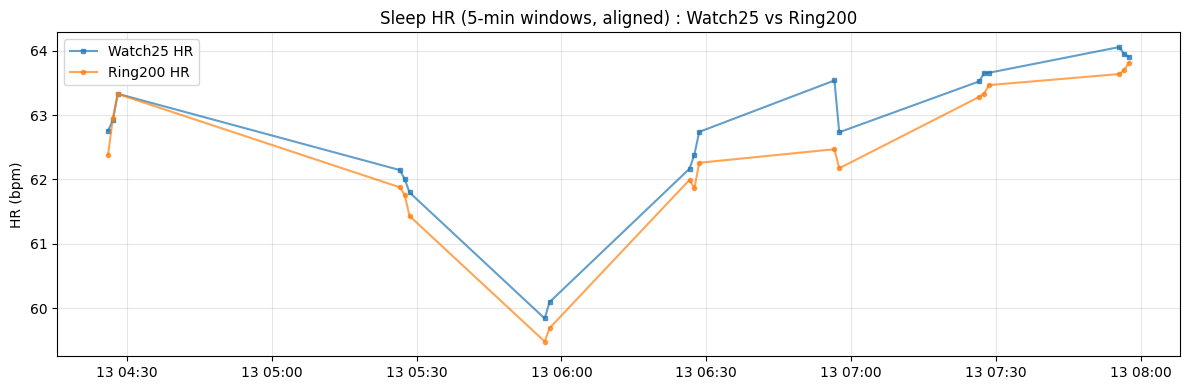

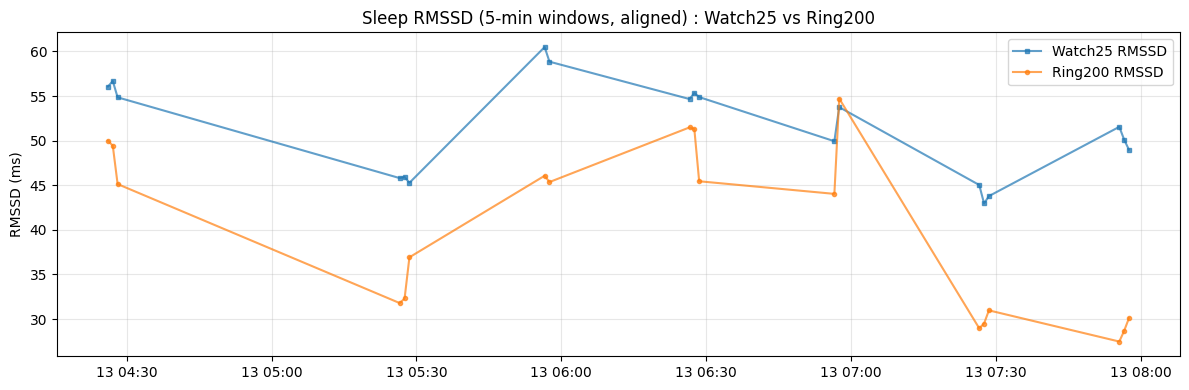

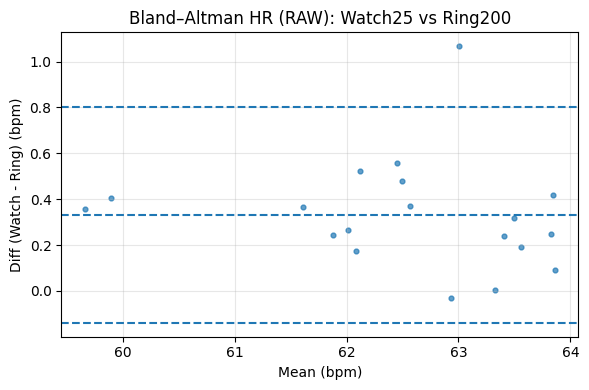

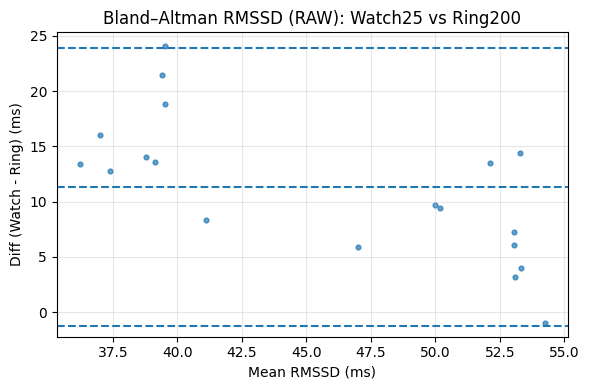

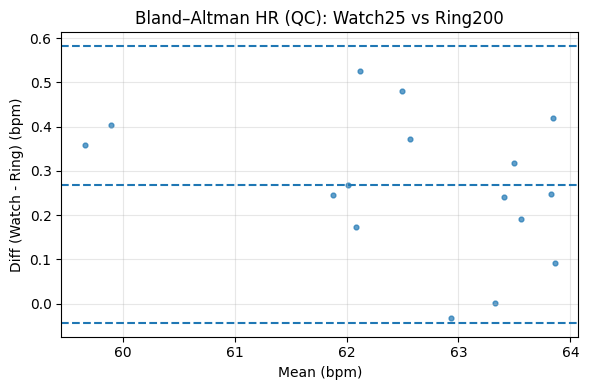

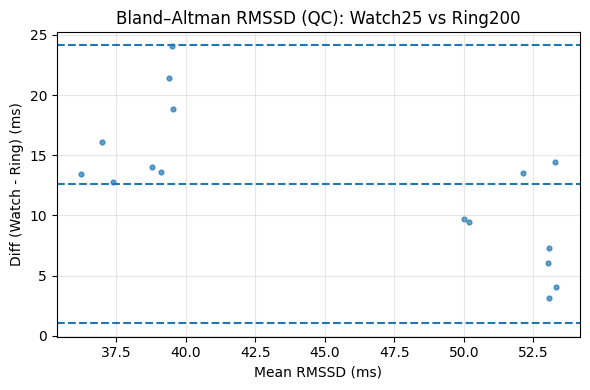

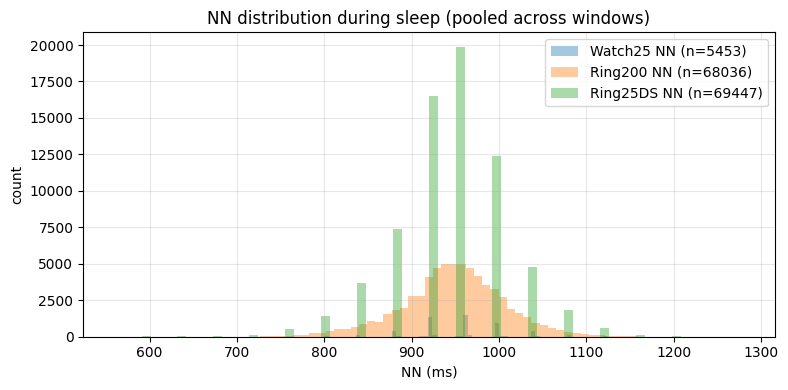

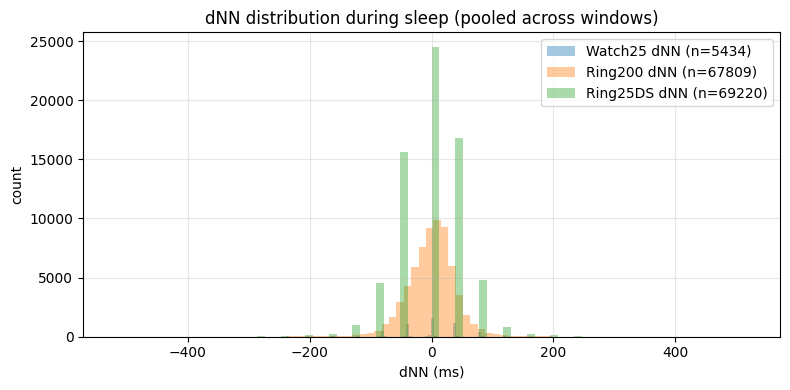

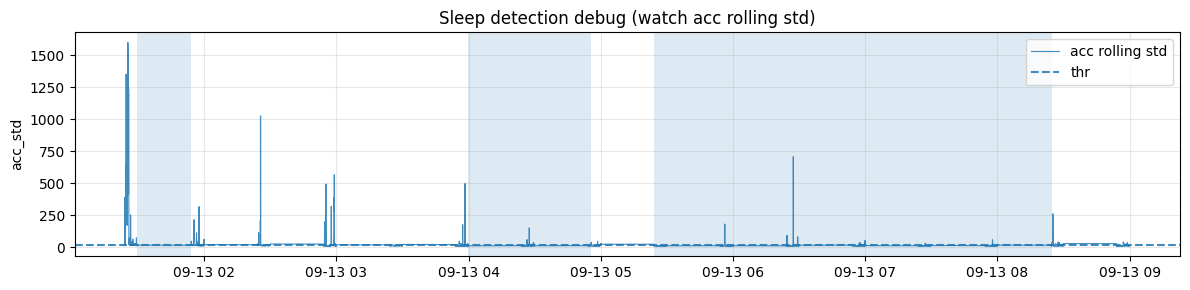


Saved files:
 - ./sleep_watch25_vs_ring200/sleep_window_metrics_watch25_vs_ring200.csv
 - ./sleep_watch25_vs_ring200/sleep_window_metrics_watch25_vs_ring25ds.csv
 - ./sleep_watch25_vs_ring200/agreement_watch25_vs_ring200_raw_vs_qc.csv
 - ./sleep_watch25_vs_ring200/agreement_watch25_vs_ring25ds_raw_vs_qc.csv
 - ./sleep_watch25_vs_ring200/sleep_block_coverage_and_qc_summary.csv
Plots saved in OUT_DIR.
Done.

--------------------------------------------------------------------------------
[PASS/FAIL Summary Saved] watch25_vs_ring200
group  n_hr     r_hr  mae_hr_bpm  ba_hr_bias  ba_hr_loa_low  ba_hr_loa_high  n_rmssd  r_rmssd  mae_rmssd_ms  ba_rmssd_bias  ba_rmssd_loa_low  ba_rmssd_loa_high
 PASS    16 0.993365    0.273026    0.268991      -0.043789        0.581772       16 0.822769     12.624277      12.624277          1.074066          24.174488
 FAIL     3 0.980176    0.664123    0.664123      -0.046063        1.374310        3 0.985144      5.070988       4.428836         -5.032720   

In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend, find_peaks

# =============================================================================
# Sleep Comparison: Watch(25Hz) vs Ring(200Hz) + (Ring->25Hz downsample test)
#  - 수면구간(Watch acc 기반)만 추출
#  - 5분 윈도우(1분 step) HR/RMSSD 산출
#  - RAW(all) vs QC(both_pass) 일치도
#  - 추가:
#      (1) sleep block별 윈도우 coverage/통과율 표 저장
#      (2) NN/RR 분포(히스토그램) + dNN 분포 플롯
#      (3) Ring 200Hz를 25Hz로 다운샘플하여 샘플링 영향 분리(Watch vs Ring25DS)
# =============================================================================

# ============================================================
# CONFIG
# ============================================================
WATCH_CSV = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_Day2_cut_202509130124_202509130907.csv"
FS_WATCH  = 25.0

RING_CSV  = "/content/drive/MyDrive/Colab Notebooks/NRBI/E0001/Day2/ppgRaw.csv"
FS_RING   = 200.0
RING_START_TIME = "2025-09-13 01:24:00"   # ring time이 상대/epoch일 때 기준

OUT_DIR = "./sleep_watch25_vs_ring200"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- HR/HRV ----------
MIN_BPM = 40
MAX_BPM = 200
PROM_SCALE_WATCH = 0.10
PROM_SCALE_RING  = 0.20
PROM_SCALE_RING_DS25 = 0.12  # ring을 25Hz로 다운샘플 후 peak 탐지 prom scale (watch와 비슷하게)

WIN_SEC  = 300     # 5-min window
STEP_SEC = 60      # 1-min step

# ---------- NN cleaning ----------
RR_MIN_MS = 300
RR_MAX_MS = 2000
MAD_K     = 4.0

# ---------- QC (window pass criteria) ----------
# 경험적으로 "HRV(특히 RMSSD) 가능" 판정에 민감: 너무 세게 잡으면 n이 급감합니다.
QC_MIN_NN         = 200       # 5분에서 최소 NN 개수 (수면 HR ~60이면 대략 300 전후)
QC_MAX_REMOVE     = 0.12      # (range+MAD)로 제거된 비율 (전체 rr 대비)
QC_MAX_OUTLIER    = 0.15      # (MAD outlier) 비율 (range 통과분 대비)
QC_MAX_RR_CV      = 0.20      # NN의 CV 상한(너무 크면 peak 문제 가능)
QC_MAX_JUMP_RATE  = 0.10      # |dNN|>200ms 비율
QC_MIN_SNR_DB     = -35.0     # 현재 데이터가 -40~-25 dB라서 느슨하게(필요 시 조정)

# ---------- 수면 구간(Watch acc_std 기반) ----------
ACC_ROLL_SEC = 5.0
SLEEP_MIN_DUR_MIN = 20
MERGE_GAP_MIN = 5
ACC_STD_THR_FORCE = None  # None이면 자동(하위 분위수 기반), 필요시 수동 설정

# ---------- 다운샘플 테스트 ----------
DO_RING_DOWNSAMPLE_25 = True
FS_RING_DS = 25.0  # 링 다운샘플 타겟 fs


# ============================================================
# UTIL
# ============================================================
def read_csv_robust(path: str) -> pd.DataFrame:
    """CSV 읽기 - 헤더 자동 감지(첫 행이 숫자면 header=None)"""
    df = pd.read_csv(path)
    def is_numberish(x):
        try:
            float(str(x).strip()); return True
        except: return False
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df

def pick_time_col(df: pd.DataFrame):
    cand = ["time", "Time", "timestamp", "Timestamp", "sample_or_time", "sample_time", "t",
            "sample_index", "index", "Index", 0]
    for c in cand:
        if c in df.columns:
            return c
    return df.columns[0]

def infer_ppg_col(df: pd.DataFrame, time_col) -> str:
    exclude_keywords = ['sleep', 'step', 'battery', 'quality', 'flag', 'stage',
                        'day', 'month', 'year', 'date', 'index', 'cnt', 'count',
                        'acc', 'gyro', 'motion', 'axis', '_x', '_y', '_z']
    candidates = []
    for c in df.columns:
        if c == time_col:
            continue
        if any(k in str(c).lower() for k in exclude_keywords):
            continue
        try:
            pd.to_numeric(df[c])
            candidates.append(c)
        except:
            pass

    num_cols = [c for c in candidates if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) == 0:
        num_cols = [c for c in df.columns if c != time_col and pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) == 0:
        if df.shape[1] == 2:
            return df.columns[1]
        raise ValueError(f"PPG 컬럼 추정 실패. columns={df.columns.tolist()}")
    return num_cols[0]

def build_datetime_smart(df: pd.DataFrame, time_col, fs: float, start_time: str = None) -> pd.Series:
    """
    시간 컬럼을 datetime으로 변환
    - datetime string이면 직접 파싱 (단 1970 과다이면 reject)
    - 숫자면 unit 추정 + start_time 적용
    """
    dt_try = pd.to_datetime(df[time_col], errors="coerce")
    valid_ratio = dt_try.notna().sum() / len(df)
    print(f"  DateTime parsing: {valid_ratio*100:.1f}% valid")

    if valid_ratio > 0.9:
        valid_dates = dt_try[dt_try.notna()]
        if len(valid_dates) > 0:
            year_1970_ratio = (valid_dates.dt.year == 1970).sum() / len(valid_dates)
            print(f"  1970 year ratio: {year_1970_ratio*100:.1f}%")
            if year_1970_ratio < 0.5:
                print("  Using direct datetime parsing")
                return dt_try
            else:
                print("  Rejecting datetime parsing (too many 1970)")

    print("  Attempting numeric timestamp parsing...")
    ts = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    valid_ts = ts[np.isfinite(ts)]
    if len(valid_ts) < 100:
        raise ValueError(f"유효 timestamp가 너무 적습니다: {len(valid_ts)}")

    diffs = np.diff(valid_ts[:min(1000, len(valid_ts))])
    diffs = diffs[diffs > 0]

    unit, divisor = 's', 1.0
    if len(diffs) > 0:
        median_diff = np.median(diffs)
        expected_interval = 1.0 / fs
        if abs(median_diff - expected_interval * 1e9) < expected_interval * 1e9 * 0.5:
            unit, divisor = 'ns', 1e9
        elif abs(median_diff - expected_interval * 1e6) < expected_interval * 1e6 * 0.5:
            unit, divisor = 'us', 1e6
        elif abs(median_diff - expected_interval * 1e3) < expected_interval * 1e3 * 0.5:
            unit, divisor = 'ms', 1e3
        elif abs(median_diff - expected_interval) < expected_interval * 0.5:
            unit, divisor = 's', 1.0
        elif abs(median_diff - 1.0) < 0.5:
            unit, divisor = 'samples', fs
        else:
            if median_diff > 1e6:
                unit, divisor = 'ns', 1e9
            elif median_diff > 1000:
                unit, divisor = 'us', 1e6
            elif median_diff > 1:
                unit, divisor = 'ms', 1e3
            else:
                unit, divisor = 's', 1.0

    print(f"  Detected unit: {unit} (divisor={divisor:.0e})")

    t_seconds = (ts - ts[0]) / divisor
    t_seconds = np.nan_to_num(t_seconds, nan=0.0)

    if start_time is None:
        raise ValueError("숫자 타임스탬프는 start_time이 필요합니다!")
    dt = pd.to_datetime(start_time) + pd.to_timedelta(t_seconds, unit="s")
    return pd.Series(dt)

def preprocess_ppg(x: np.ndarray, fs: float) -> np.ndarray:
    """detrend + bandpass (MIN_BPM~MAX_BPM)"""
    x = np.asarray(x, dtype=float)
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    if len(x) < 50:
        return x - np.nanmean(x)

    x0 = detrend(x)

    nyq = 0.5 * fs
    lo = max((MIN_BPM/60.0) / nyq, 1e-6)
    hi = min((MAX_BPM/60.0) / nyq, 0.999)

    b, a = butter(2 if fs < 50 else 4, [lo, hi], btype="band")
    padlen = 3 * max(len(a), len(b))
    if len(x0) <= padlen:
        if len(x0) <= 2 * len(b):
            return x0
        return filtfilt(b, a, x0, padlen=min(padlen, len(x0)-1))
    return filtfilt(b, a, x0)

def snr_db(raw: np.ndarray, band: np.ndarray) -> float:
    raw = np.asarray(raw, dtype=float)
    band = np.asarray(band, dtype=float)
    resid = raw - band
    vb = np.nanvar(band) + 1e-12
    vr = np.nanvar(resid) + 1e-12
    return float(10.0 * np.log10(vb / vr))

def detect_peaks(ppg_f: np.ndarray, fs: float, prom_scale: float):
    min_dist = int(round((60.0 / MAX_BPM) * fs))
    prom = prom_scale * np.nanstd(ppg_f)
    peaks, props = find_peaks(ppg_f, distance=max(1, min_dist), prominence=prom)
    return peaks, props

def nn_from_peaks(dt_series: pd.Series, peaks_idx: np.ndarray) -> np.ndarray:
    """peak index -> RR(ms) from datetime -> NN(ms)"""
    if len(peaks_idx) < 3:
        return np.array([])
    t = pd.to_datetime(dt_series.iloc[peaks_idx]).astype("datetime64[ns]").values
    rr_ms = np.diff(t) / np.timedelta64(1, "ms")
    rr_ms = rr_ms[np.isfinite(rr_ms)]
    return rr_ms.astype(float)

def compute_rmssd(nn_ms: np.ndarray) -> float:
    if len(nn_ms) < 5:
        return np.nan
    d = np.diff(nn_ms)
    return float(np.sqrt(np.mean(d**2)))

def clean_nn(rr_ms: np.ndarray,
             rr_min_ms=RR_MIN_MS, rr_max_ms=RR_MAX_MS, mad_k=MAD_K):
    """RR -> range + MAD cleaning -> NN"""
    rr_ms = np.asarray(rr_ms, dtype=float)
    rr_ms = rr_ms[np.isfinite(rr_ms)]
    if len(rr_ms) < 5:
        return np.array([]), np.nan, np.nan

    ok = (rr_ms >= rr_min_ms) & (rr_ms <= rr_max_ms)
    rr_in = rr_ms[ok]
    if len(rr_in) < 5:
        return np.array([]), 1.0, 1.0

    med = np.median(rr_in)
    mad = np.median(np.abs(rr_in - med)) + 1e-12
    ok2 = np.abs(rr_in - med) <= mad_k * mad
    nn = rr_in[ok2]

    remove_rate  = 1.0 - (len(nn) / (len(rr_ms) + 1e-12))
    outlier_rate = 1.0 - (len(nn) / (len(rr_in) + 1e-12))
    return nn.astype(float), float(remove_rate), float(outlier_rate)

def rr_quality_stats(nn_ms: np.ndarray, jump_thr_ms=200.0):
    nn_ms = np.asarray(nn_ms, dtype=float)
    nn_ms = nn_ms[np.isfinite(nn_ms)]
    if len(nn_ms) < 5:
        return {
            "rr_cv": np.nan,
            "med_abs_drr_ms": np.nan,
            "rr_jump_rate": np.nan,
            "rmssd_ratio": np.nan
        }
    rr_cv = float(np.std(nn_ms, ddof=1) / (np.mean(nn_ms) + 1e-12))
    dnn = np.diff(nn_ms)
    med_abs_drr = float(np.median(np.abs(dnn)))
    rr_jump_rate = float(np.mean(np.abs(dnn) > jump_thr_ms))

    rmssd = compute_rmssd(nn_ms)
    rmssd_ratio = float(rmssd / (np.mean(nn_ms) + 1e-12)) if np.isfinite(rmssd) else np.nan

    return {
        "rr_cv": rr_cv,
        "med_abs_drr_ms": med_abs_drr,
        "rr_jump_rate": rr_jump_rate,
        "rmssd_ratio": rmssd_ratio
    }

def window_metrics(dt: pd.Series, ppg: np.ndarray, fs: float, prom_scale: float,
                   win_sec=300, step_sec=60,
                   # QC thresholds (can override)
                   qc_min_nn=QC_MIN_NN,
                   qc_max_remove=QC_MAX_REMOVE,
                   qc_max_outlier=QC_MAX_OUTLIER,
                   qc_max_rr_cv=QC_MAX_RR_CV,
                   qc_max_jump_rate=QC_MAX_JUMP_RATE,
                   qc_min_snr_db=QC_MIN_SNR_DB):
    """
    5분 윈도우별 HR(mean), RMSSD, nNN, remove_rate, outlier_rate + 품질지표/패스 계산
    반환: df, nn_pool(list), dnn_pool(list)
    """
    dt = pd.to_datetime(pd.Series(dt)).reset_index(drop=True)
    ppg = np.asarray(ppg, dtype=float)

    # 전체 필터링(시간축 그대로, 값만)
    ppg_f = preprocess_ppg(ppg, fs)
    ref_snr = snr_db(ppg, ppg_f)

    t0 = dt.min()
    t1 = dt.max()
    if pd.isna(t0) or pd.isna(t1) or (t1 <= t0):
        return pd.DataFrame(), [], [], ref_snr

    centers = pd.date_range(
        t0 + pd.Timedelta(seconds=win_sec/2),
        t1 - pd.Timedelta(seconds=win_sec/2),
        freq=pd.Timedelta(seconds=step_sec)
    )

    rows = []
    nn_pool = []
    dnn_pool = []

    min_samples = int(0.8 * win_sec * fs)  # 윈도우 유효 샘플 최소치
    for c in centers:
        w0 = c - pd.Timedelta(seconds=win_sec/2)
        w1 = c + pd.Timedelta(seconds=win_sec/2)
        m = (dt >= w0) & (dt <= w1)
        if m.sum() < min_samples:
            continue

        dtw = dt[m].reset_index(drop=True)
        yw  = ppg_f[m]
        raww = ppg[m]

        peaks, _ = detect_peaks(yw, fs, prom_scale)
        rr_ms = nn_from_peaks(dtw, peaks)
        nn, remove_rate, outlier_rate = clean_nn(rr_ms)

        hr_mean = float(60000.0 / np.mean(nn)) if len(nn) >= 5 else np.nan
        rmssd  = compute_rmssd(nn)
        stats  = rr_quality_stats(nn)

        # window SNR(필터 기준)
        ywin_f = preprocess_ppg(raww, fs)
        snr_w  = snr_db(raww, ywin_f)

        # QC pass
        pass_flag = (
            (len(nn) >= qc_min_nn) and
            (np.isfinite(remove_rate) and remove_rate <= qc_max_remove) and
            (np.isfinite(outlier_rate) and outlier_rate <= qc_max_outlier) and
            (np.isfinite(stats["rr_cv"]) and stats["rr_cv"] <= qc_max_rr_cv) and
            (np.isfinite(stats["rr_jump_rate"]) and stats["rr_jump_rate"] <= qc_max_jump_rate) and
            (np.isfinite(snr_w) and snr_w >= qc_min_snr_db)
        )

        rows.append({
            "center": c,
            "hr_mean": hr_mean,
            "rmssd": rmssd,
            "n_nn": int(len(nn)),
            "remove_rate": remove_rate,
            "outlier_rate": outlier_rate,
            "rr_cv": stats["rr_cv"],
            "rmssd_ratio": stats["rmssd_ratio"],
            "med_abs_drr_ms": stats["med_abs_drr_ms"],
            "rr_jump_rate": stats["rr_jump_rate"],
            "snr_db": snr_w,
            "pass_qc": bool(pass_flag),
        })

        if len(nn) >= 5:
            nn_pool.extend(nn.tolist())
            dnn_pool.extend(np.diff(nn).tolist())

    df = pd.DataFrame(rows)
    return df, nn_pool, dnn_pool, ref_snr

def bland_altman(a, b):
    """bias(=mean diff), LoA"""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan, np.nan, np.nan, int(m.sum())
    d = a[m] - b[m]
    bias = float(np.mean(d))
    sd = float(np.std(d, ddof=1))
    loa_low  = bias - 1.96 * sd
    loa_high = bias + 1.96 * sd
    return bias, float(loa_low), float(loa_high), int(m.sum())

def corrcoef(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan, int(m.sum())
    return float(np.corrcoef(a[m], b[m])[0, 1]), int(m.sum())

def mae(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 1:
        return np.nan, int(m.sum())
    return float(np.mean(np.abs(a[m] - b[m]))), int(m.sum())

def downsample_to_fs(dt: pd.Series, x: np.ndarray, fs_new: float):
    """
    datetime 축 기반 선형 보간 다운샘플 (NaN 보간 포함)
    반환: dt_new(pd.Series), x_new(np.ndarray)
    """
    dt = pd.to_datetime(pd.Series(dt)).reset_index(drop=True)
    x = np.asarray(x, dtype=float)

    # NaN 보간
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    t_ns = dt.astype("datetime64[ns]").values.astype(np.int64)
    keep = np.concatenate([[True], np.diff(t_ns) > 0])
    t_ns = t_ns[keep]
    x = x[keep]

    if len(t_ns) < 10:
        return pd.Series([], dtype="datetime64[ns]"), np.array([], dtype=float)

    t0 = t_ns[0]
    t_sec = (t_ns - t0) / 1e9

    dur = float(t_sec[-1] - t_sec[0])
    if dur <= 0:
        return pd.Series([], dtype="datetime64[ns]"), np.array([], dtype=float)

    step = 1.0 / float(fs_new)
    t_new = np.arange(0.0, dur + 1e-9, step, dtype=float)

    # numpy interp는 x축이 증가해야 함
    x_new = np.interp(t_new, t_sec, x)

    dt_new = pd.to_datetime(t0) + pd.to_timedelta(t_new, unit="s")
    return pd.Series(dt_new), x_new

# ============================================================
# LOADERS
# ============================================================
def load_watch_new_format(csv_path: str):
    """
    Watch 새 포맷: timestamp, time, ppg, acc_x/y/z 가 있다고 가정
    """
    df = pd.read_csv(csv_path)
    print(f"[Watch] shape={df.shape}, columns={df.columns.tolist()}")

    if "time" not in df.columns:
        raise ValueError(f"'time' 컬럼이 없습니다: {df.columns.tolist()}")
    if "ppg" not in df.columns:
        raise ValueError(f"'ppg' 컬럼이 없습니다: {df.columns.tolist()}")

    dt = pd.to_datetime(df["time"], errors="coerce")
    ppg = pd.to_numeric(df["ppg"], errors="coerce").to_numpy(dtype=float)

    acc = None
    cand_sets = [("acc_x","acc_y","acc_z"), ("ACC_X","ACC_Y","ACC_Z"), ("ax","ay","az")]
    for a,b,c in cand_sets:
        if a in df.columns and b in df.columns and c in df.columns:
            ax = pd.to_numeric(df[a], errors="coerce").to_numpy(dtype=float)
            ay = pd.to_numeric(df[b], errors="coerce").to_numpy(dtype=float)
            az = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
            acc = np.vstack([ax,ay,az]).T
            break

    print(f"[Watch] Time range: {dt.min()} ~ {dt.max()}")
    return df, dt, ppg, acc

def load_ring_old_format(csv_path: str, fs: float, start_time: str, target_col=None):
    df = read_csv_robust(csv_path)
    time_col = pick_time_col(df)

    # target_col 처리
    if target_col is not None:
        if isinstance(target_col, str) and target_col.isdigit():
            ppg_col = df.columns[int(target_col)]
        elif target_col in df.columns:
            ppg_col = target_col
        else:
            ppg_col = infer_ppg_col(df, time_col)
    else:
        ppg_col = infer_ppg_col(df, time_col)

    print(f"[Ring] shape={df.shape}, time_col={time_col}, ppg_col={ppg_col}")
    dt = build_datetime_smart(df, time_col, fs, start_time=start_time)
    ppg = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    print(f"[Ring] Time range: {dt.min()} ~ {dt.max()}")
    return df, dt, ppg

# ============================================================
# SLEEP DETECTION (Watch)
# ============================================================
def mask_to_intervals(dt: pd.Series, mask: np.ndarray, min_dur_min=20, merge_gap_min=5):
    dt = pd.to_datetime(pd.Series(dt)).reset_index(drop=True)
    mask = np.asarray(mask, dtype=bool)
    n = min(len(dt), len(mask))
    dt = dt.iloc[:n]
    mask = mask[:n]

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []

    breaks = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[idx[0], idx[breaks+1]]
    ends   = np.r_[idx[breaks], idx[-1]]

    intervals = []
    for s, e in zip(starts, ends):
        t0 = dt.iloc[s]
        t1 = dt.iloc[e]
        dur_min = (t1 - t0).total_seconds() / 60.0
        if dur_min >= min_dur_min:
            intervals.append([t0, t1])

    if len(intervals) <= 1:
        return [(a,b) for a,b in intervals]

    merged = [intervals[0]]
    gap_thr = merge_gap_min * 60.0
    for a,b in intervals[1:]:
        prev_a, prev_b = merged[-1]
        gap = (a - prev_b).total_seconds()
        if gap <= gap_thr:
            merged[-1][1] = b
        else:
            merged.append([a,b])

    return [(a,b) for a,b in merged]

def detect_sleep_intervals_watch(df_watch: pd.DataFrame, dt_watch: pd.Series, fs_watch: float,
                                 acc: np.ndarray,
                                 roll_sec=5.0, min_dur_min=20, merge_gap_min=5,
                                 thr_force=None):
    """
    우선:
      - sleep/stage 컬럼 있으면 사용(가능한 경우)
      - 아니면 acc rolling std 기반
    """
    dt_watch = pd.to_datetime(pd.Series(dt_watch)).reset_index(drop=True)

    sleep_like_cols = [c for c in df_watch.columns if any(k in str(c).lower() for k in ["sleep", "stage"])]
    if len(sleep_like_cols) > 0:
        c = sleep_like_cols[0]
        s = df_watch[c].astype(str).str.lower()
        asleep = ~s.str.contains("awake")
        asleep = asleep.fillna(False).to_numpy(dtype=bool)
        intervals = mask_to_intervals(dt_watch, asleep, min_dur_min=min_dur_min, merge_gap_min=merge_gap_min)
        return intervals, {"mode": "sleep_col", "sleep_col": c, "asleep_mask": asleep}

    if acc is None:
        raise ValueError("watch에 acc 컬럼이 없어서 수면 구간 자동 추정이 불가합니다. (sleep/stage 컬럼도 없음)")

    ax, ay, az = acc[:,0], acc[:,1], acc[:,2]
    mag = np.sqrt(ax*ax + ay*ay + az*az)
    mag = pd.Series(mag).interpolate(limit_direction="both").to_numpy(dtype=float)

    roll_n = int(max(1, round(roll_sec * fs_watch)))
    acc_std = pd.Series(mag).rolling(roll_n, center=True, min_periods=roll_n).std().to_numpy()
    acc_std = np.nan_to_num(acc_std, nan=np.nanmedian(acc_std))

    if thr_force is None:
        base = np.nanpercentile(acc_std, 20)
        thr = base * 1.5
    else:
        thr = float(thr_force)

    asleep = acc_std < thr
    intervals = mask_to_intervals(dt_watch, asleep, min_dur_min=min_dur_min, merge_gap_min=merge_gap_min)
    dbg = {"mode": "acc_std", "thr": thr, "acc_std": acc_std, "asleep_mask": asleep}
    return intervals, dbg

# ============================================================
# MAIN
# ============================================================
print("="*80)
print("Sleep Comparison: Watch (25Hz) vs Ring (200Hz) (+ Ring->25Hz DS test)")
print("="*80)

# 1) Load Watch
df_watch, dt_watch, ppg_watch, acc_watch = load_watch_new_format(WATCH_CSV)

# 2) Load Ring
df_ring, dt_ring, ppg_ring = load_ring_old_format(RING_CSV, FS_RING, RING_START_TIME, target_col="1")

# 3) Common overlap
start = max(pd.to_datetime(dt_watch).min(), pd.to_datetime(dt_ring).min())
end   = min(pd.to_datetime(dt_watch).max(), pd.to_datetime(dt_ring).max())
print(f"\n[Common Overlap] {start} ~ {end}")
if (end - start).total_seconds() <= 0:
    raise ValueError("Watch/Ring 시간이 겹치지 않습니다. RING_START_TIME/파일을 확인하세요.")

m_w = (pd.to_datetime(dt_watch) >= start) & (pd.to_datetime(dt_watch) <= end)
m_r = (pd.to_datetime(dt_ring)  >= start) & (pd.to_datetime(dt_ring)  <= end)

dt_watch_c = pd.Series(pd.to_datetime(dt_watch)[m_w]).reset_index(drop=True)
ppg_watch_c = ppg_watch[m_w]
acc_watch_c = acc_watch[m_w] if acc_watch is not None else None

dt_ring_c = pd.Series(pd.to_datetime(dt_ring)[m_r]).reset_index(drop=True)
ppg_ring_c = ppg_ring[m_r]

print(f"[Cut] Watch: {len(ppg_watch_c)} samples ({len(ppg_watch_c)/FS_WATCH:.1f}s)")
print(f"[Cut] Ring : {len(ppg_ring_c)} samples ({len(ppg_ring_c)/FS_RING:.1f}s)")

# 4) Detect sleep intervals (from Watch)
sleep_intervals, sleep_dbg = detect_sleep_intervals_watch(
    df_watch.loc[m_w].reset_index(drop=True),
    dt_watch_c, FS_WATCH,
    acc_watch_c,
    roll_sec=ACC_ROLL_SEC,
    min_dur_min=SLEEP_MIN_DUR_MIN,
    merge_gap_min=MERGE_GAP_MIN,
    thr_force=ACC_STD_THR_FORCE
)

print("\n[Sleep Detection]")
print(f"  mode={sleep_dbg.get('mode')}")
if sleep_dbg.get("mode") == "acc_std":
    print(f"  acc_std_thr={sleep_dbg.get('thr'):.6f}")
print(f"  intervals={len(sleep_intervals)}")
for i,(a,b) in enumerate(sleep_intervals[:10]):
    print(f"   - #{i+1}: {a} ~ {b}  ({(b-a).total_seconds()/60:.1f} min)")
if len(sleep_intervals) == 0:
    raise ValueError("수면 구간을 찾지 못했습니다. (ACC_STD_THR_FORCE/min_dur/merge 조정 필요)")

# 5) Per-block metrics & align
all_rows_ring200 = []
all_rows_ring25  = []

# pooled NN for distribution plots
nn_pool_watch, dnn_pool_watch = [], []
nn_pool_ring200, dnn_pool_ring200 = [], []
nn_pool_ring25, dnn_pool_ring25 = [], []

block_rows = []  # sleep block summary table

for block_id, (a, b) in enumerate(sleep_intervals, start=1):
    mw = (dt_watch_c >= a) & (dt_watch_c <= b)
    mr = (dt_ring_c  >= a) & (dt_ring_c  <= b)

    dtw = dt_watch_c[mw].reset_index(drop=True)
    xw  = ppg_watch_c[mw]

    dtr = dt_ring_c[mr].reset_index(drop=True)
    xr  = ppg_ring_c[mr]

    # 최소 길이 체크 (5분 윈도우 계산 가능성)
    if len(xw) < WIN_SEC * FS_WATCH * 0.8 or len(xr) < WIN_SEC * FS_RING * 0.8:
        continue

    w_df, w_nn, w_dnn, w_refsnr = window_metrics(
        dtw, xw, FS_WATCH, PROM_SCALE_WATCH,
        win_sec=WIN_SEC, step_sec=STEP_SEC
    )
    r_df, r_nn, r_dnn, r_refsnr = window_metrics(
        dtr, xr, FS_RING, PROM_SCALE_RING,
        win_sec=WIN_SEC, step_sec=STEP_SEC
    )

    if len(w_df) == 0 or len(r_df) == 0:
        continue

    nn_pool_watch.extend(w_nn); dnn_pool_watch.extend(w_dnn)
    nn_pool_ring200.extend(r_nn); dnn_pool_ring200.extend(r_dnn)

    w_df = w_df.sort_values("center")
    r_df = r_df.sort_values("center")

    merged200 = pd.merge_asof(
        w_df, r_df, on="center",
        direction="nearest",
        tolerance=pd.Timedelta(seconds=STEP_SEC/2),
        suffixes=("_watch", "_ring200")
    )
    merged200["sleep_block"] = block_id
    merged200["sleep_start"] = a
    merged200["sleep_end"]   = b
    all_rows_ring200.append(merged200)

    # ring -> 25Hz downsample test (sampling effect isolation)
    merged25 = None
    if DO_RING_DOWNSAMPLE_25:
        dt_r25, x_r25 = downsample_to_fs(dtr, xr, fs_new=FS_RING_DS)
        if len(x_r25) >= WIN_SEC * FS_RING_DS * 0.8:
            r25_df, r25_nn, r25_dnn, r25_refsnr = window_metrics(
                dt_r25, x_r25, FS_RING_DS, PROM_SCALE_RING_DS25,
                win_sec=WIN_SEC, step_sec=STEP_SEC
            )
            if len(r25_df) > 0:
                nn_pool_ring25.extend(r25_nn); dnn_pool_ring25.extend(r25_dnn)

                r25_df = r25_df.sort_values("center")
                merged25 = pd.merge_asof(
                    w_df, r25_df, on="center",
                    direction="nearest",
                    tolerance=pd.Timedelta(seconds=STEP_SEC/2),
                    suffixes=("_watch", "_ring25ds")
                )
                merged25["sleep_block"] = block_id
                merged25["sleep_start"] = a
                merged25["sleep_end"]   = b
                all_rows_ring25.append(merged25)

    # block summary stats (coverage & QC)
    # ring200
    n_merge200 = int(merged200["hr_mean_watch"].notna().sum() & merged200["hr_mean_ring200"].notna().sum()) if len(merged200) else 0
    # QC both pass
    if len(merged200):
        both_pass200 = (merged200["pass_qc_watch"] == True) & (merged200["pass_qc_ring200"] == True)
        n_qc200 = int(np.sum(both_pass200))
        passrate_qc200 = float(np.mean(both_pass200)) if len(both_pass200) else np.nan
    else:
        n_qc200, passrate_qc200 = 0, np.nan

    # ring25ds
    if merged25 is not None and len(merged25):
        both_pass25 = (merged25["pass_qc_watch"] == True) & (merged25["pass_qc_ring25ds"] == True)
        n_qc25 = int(np.sum(both_pass25))
        passrate_qc25 = float(np.mean(both_pass25)) if len(both_pass25) else np.nan
        n_merge25 = int(len(merged25))
    else:
        n_merge25, n_qc25, passrate_qc25 = 0, 0, np.nan

    block_rows.append({
        "sleep_block": block_id,
        "sleep_start": a,
        "sleep_end": b,
        "dur_min": (b-a).total_seconds()/60.0,
        "n_win_watch": int(len(w_df)),
        "watch_qc_pass_rate": float(w_df["pass_qc"].mean()) if len(w_df) else np.nan,
        "n_win_ring200": int(len(r_df)),
        "ring200_qc_pass_rate": float(r_df["pass_qc"].mean()) if len(r_df) else np.nan,
        "n_aligned_ring200": int(len(merged200)),
        "n_bothpass_ring200": n_qc200,
        "bothpass_rate_ring200": passrate_qc200,
        "n_aligned_ring25ds": n_merge25,
        "n_bothpass_ring25ds": n_qc25,
        "bothpass_rate_ring25ds": passrate_qc25
    })

if len(all_rows_ring200) == 0:
    raise ValueError("수면 구간에서 비교 가능한 윈도우가 없습니다. (WIN/STEP, sleep 파라미터 조정 필요)")

cmp200 = pd.concat(all_rows_ring200, ignore_index=True)
cmp25  = pd.concat(all_rows_ring25, ignore_index=True) if len(all_rows_ring25) else pd.DataFrame()
block_df = pd.DataFrame(block_rows)

# 6) Agreement summary (RAW vs QC)
def agreement_table(cmp_df: pd.DataFrame, suffix_b: str, tag: str):
    """
    cmp_df columns:
      hr_mean_watch, rmssd_watch, pass_qc_watch
      hr_mean_<suffix_b>, rmssd_<suffix_b>, pass_qc_<suffix_b>
    """
    out = {}
    a_hr = cmp_df["hr_mean_watch"]
    b_hr = cmp_df[f"hr_mean_{suffix_b}"]
    a_rm = cmp_df["rmssd_watch"]
    b_rm = cmp_df[f"rmssd_{suffix_b}"]

    r_hr, n_hr = corrcoef(a_hr, b_hr)
    mae_hr, _ = mae(a_hr, b_hr)
    ba_hr_bias, ba_hr_low, ba_hr_high, _ = bland_altman(a_hr, b_hr)

    r_rm, n_rm = corrcoef(a_rm, b_rm)
    mae_rm, _ = mae(a_rm, b_rm)
    ba_rm_bias, ba_rm_low, ba_rm_high, _ = bland_altman(a_rm, b_rm)

    out.update({
        "tag": tag,
        "n_hr": n_hr,
        "r_hr": r_hr,
        "mae_hr_bpm": mae_hr,
        "n_rmssd": n_rm,
        "r_rmssd": r_rm,
        "mae_rmssd_ms": mae_rm,
        "ba_hr_bias": ba_hr_bias,
        "ba_hr_loa_low": ba_hr_low,
        "ba_hr_loa_high": ba_hr_high,
        "ba_rmssd_bias": ba_rm_bias,
        "ba_rmssd_loa_low": ba_rm_low,
        "ba_rmssd_loa_high": ba_rm_high
    })
    return out

rows = []
# RAW(all)
rows.append(agreement_table(cmp200, "ring200", "RAW(all)"))

# QC(both_pass)
both_pass200 = (cmp200["pass_qc_watch"] == True) & (cmp200["pass_qc_ring200"] == True)
rows.append(agreement_table(cmp200.loc[both_pass200].reset_index(drop=True), "ring200", "QC(both_pass)"))

agree200 = pd.DataFrame(rows)

print("\n" + "="*80)
print("[Sleep Window Agreement: Watch25 vs Ring200] (RAW vs QC)")
print("="*80)
print(agree200.to_string(index=False))

agree200.to_csv(os.path.join(OUT_DIR, "agreement_watch25_vs_ring200_raw_vs_qc.csv"), index=False)

# 추가: Watch vs Ring25DS (선택)
agree25 = None
if len(cmp25):
    rows2 = []
    rows2.append(agreement_table(cmp25, "ring25ds", "RAW(all)"))
    both_pass25 = (cmp25["pass_qc_watch"] == True) & (cmp25["pass_qc_ring25ds"] == True)
    rows2.append(agreement_table(cmp25.loc[both_pass25].reset_index(drop=True), "ring25ds", "QC(both_pass)"))
    agree25 = pd.DataFrame(rows2)
    print("\n" + "="*80)
    print("[Sleep Window Agreement: Watch25 vs Ring25DS] (sampling-effect test)")
    print("="*80)
    print(agree25.to_string(index=False))
    agree25.to_csv(os.path.join(OUT_DIR, "agreement_watch25_vs_ring25ds_raw_vs_qc.csv"), index=False)

# 7) Save main window-level CSVs
cmp200.to_csv(os.path.join(OUT_DIR, "sleep_window_metrics_watch25_vs_ring200.csv"), index=False)
if len(cmp25):
    cmp25.to_csv(os.path.join(OUT_DIR, "sleep_window_metrics_watch25_vs_ring25ds.csv"), index=False)

# 8) Save block summary
block_df.to_csv(os.path.join(OUT_DIR, "sleep_block_coverage_and_qc_summary.csv"), index=False)

# 9) Plots: HR/RMSSD aligned time series (Ring200)
plt.figure(figsize=(12,4))
plt.plot(cmp200["center"], cmp200["hr_mean_watch"], "s-", markersize=3, alpha=0.7, label="Watch25 HR")
plt.plot(cmp200["center"], cmp200["hr_mean_ring200"], "o-", markersize=3, alpha=0.7, label="Ring200 HR")
plt.ylabel("HR (bpm)")
plt.title("Sleep HR (5-min windows, aligned) : Watch25 vs Ring200")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sleep_hr_watch25_vs_ring200.png"), dpi=150)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(cmp200["center"], cmp200["rmssd_watch"], "s-", markersize=3, alpha=0.7, label="Watch25 RMSSD")
plt.plot(cmp200["center"], cmp200["rmssd_ring200"], "o-", markersize=3, alpha=0.7, label="Ring200 RMSSD")
plt.ylabel("RMSSD (ms)")
plt.title("Sleep RMSSD (5-min windows, aligned) : Watch25 vs Ring200")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sleep_rmssd_watch25_vs_ring200.png"), dpi=150)
plt.show()

# 10) Plots: Bland–Altman (Ring200) RAW vs QC
def plot_ba(cmp_df, suffix_b, title, fname):
    a = np.asarray(cmp_df["hr_mean_watch"], dtype=float)
    b = np.asarray(cmp_df[f"hr_mean_{suffix_b}"], dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() >= 3:
        diff = a[m] - b[m]
        meanv = 0.5*(a[m] + b[m])
        bias = np.mean(diff)
        sd = np.std(diff, ddof=1)
        loa_low, loa_high = bias - 1.96*sd, bias + 1.96*sd
        plt.figure(figsize=(6,4))
        plt.scatter(meanv, diff, s=12, alpha=0.7)
        plt.axhline(bias, linestyle="--")
        plt.axhline(loa_low, linestyle="--")
        plt.axhline(loa_high, linestyle="--")
        plt.xlabel("Mean (bpm)")
        plt.ylabel("Diff (Watch - Ring) (bpm)")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
        plt.show()

def plot_ba_rmssd(cmp_df, suffix_b, title, fname):
    a = np.asarray(cmp_df["rmssd_watch"], dtype=float)
    b = np.asarray(cmp_df[f"rmssd_{suffix_b}"], dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() >= 3:
        diff = a[m] - b[m]
        meanv = 0.5*(a[m] + b[m])
        bias = np.mean(diff)
        sd = np.std(diff, ddof=1)
        loa_low, loa_high = bias - 1.96*sd, bias + 1.96*sd
        plt.figure(figsize=(6,4))
        plt.scatter(meanv, diff, s=12, alpha=0.7)
        plt.axhline(bias, linestyle="--")
        plt.axhline(loa_low, linestyle="--")
        plt.axhline(loa_high, linestyle="--")
        plt.xlabel("Mean RMSSD (ms)")
        plt.ylabel("Diff (Watch - Ring) (ms)")
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
        plt.show()

# BA (RAW)
plot_ba(cmp200, "ring200", "Bland–Altman HR (RAW): Watch25 vs Ring200", "ba_hr_raw_watch25_vs_ring200.png")
plot_ba_rmssd(cmp200, "ring200", "Bland–Altman RMSSD (RAW): Watch25 vs Ring200", "ba_rmssd_raw_watch25_vs_ring200.png")

# BA (QC both pass)
cmp200_qc = cmp200.loc[(cmp200["pass_qc_watch"]==True) & (cmp200["pass_qc_ring200"]==True)].reset_index(drop=True)
plot_ba(cmp200_qc, "ring200", "Bland–Altman HR (QC): Watch25 vs Ring200", "ba_hr_qc_watch25_vs_ring200.png")
plot_ba_rmssd(cmp200_qc, "ring200", "Bland–Altman RMSSD (QC): Watch25 vs Ring200", "ba_rmssd_qc_watch25_vs_ring200.png")

# 11) Distribution plots: NN and dNN (Watch vs Ring200 vs Ring25DS)
def hist_plot(data_list, labels, title, xlabel, fname, bins=60):
    plt.figure(figsize=(8,4))
    for d, lab in zip(data_list, labels):
        d = np.asarray(d, dtype=float)
        d = d[np.isfinite(d)]
        if len(d) == 0:
            continue
        plt.hist(d, bins=bins, alpha=0.4, label=f"{lab} (n={len(d)})")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
    plt.show()

hist_plot(
    [nn_pool_watch, nn_pool_ring200, nn_pool_ring25],
    ["Watch25 NN", "Ring200 NN", "Ring25DS NN"],
    "NN distribution during sleep (pooled across windows)",
    "NN (ms)",
    "nn_distribution_sleep.png",
    bins=70
)

hist_plot(
    [dnn_pool_watch, dnn_pool_ring200, dnn_pool_ring25],
    ["Watch25 dNN", "Ring200 dNN", "Ring25DS dNN"],
    "dNN distribution during sleep (pooled across windows)",
    "dNN (ms)",
    "dnn_distribution_sleep.png",
    bins=80
)

# 12) Sleep detection debug plot (acc_std)
if sleep_dbg.get("mode") == "acc_std":
    acc_std = sleep_dbg["acc_std"]
    asleep  = sleep_dbg["asleep_mask"]
    t = dt_watch_c.reset_index(drop=True)

    plt.figure(figsize=(12,3))
    plt.plot(t, acc_std, linewidth=0.8, alpha=0.85, label="acc rolling std")
    plt.axhline(sleep_dbg["thr"], linestyle="--", alpha=0.85, label="thr")
    for a,b in sleep_intervals:
        plt.axvspan(a, b, alpha=0.15)
    plt.title("Sleep detection debug (watch acc rolling std)")
    plt.ylabel("acc_std")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "sleep_detection_debug.png"), dpi=150)
    plt.show()

print("\n" + "="*80)
print("Saved files:")
print(f" - {os.path.join(OUT_DIR, 'sleep_window_metrics_watch25_vs_ring200.csv')}")
if len(cmp25):
    print(f" - {os.path.join(OUT_DIR, 'sleep_window_metrics_watch25_vs_ring25ds.csv')}")
print(f" - {os.path.join(OUT_DIR, 'agreement_watch25_vs_ring200_raw_vs_qc.csv')}")
if agree25 is not None:
    print(f" - {os.path.join(OUT_DIR, 'agreement_watch25_vs_ring25ds_raw_vs_qc.csv')}")
print(f" - {os.path.join(OUT_DIR, 'sleep_block_coverage_and_qc_summary.csv')}")
print("Plots saved in OUT_DIR.")
print("="*80)
print("Done.")
print("="*80)


# =============================================================================
# (ADD) PASS vs FAIL 요약 + 저장 (Watch25 vs Ring200, Watch25 vs Ring25DS)
# =============================================================================

def bland_altman_dict(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return dict(bias=np.nan, loa_low=np.nan, loa_high=np.nan, n=int(m.sum()))
    d = a[m] - b[m]
    bias = float(np.mean(d))
    sd   = float(np.std(d, ddof=1))
    return dict(bias=bias, loa_low=bias - 1.96*sd, loa_high=bias + 1.96*sd, n=int(m.sum()))

def corr_mae_dict(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return dict(r=np.nan, mae=np.nan, n=int(m.sum()))
    r = float(np.corrcoef(a[m], b[m])[0,1])
    mae = float(np.mean(np.abs(a[m]-b[m])))
    return dict(r=r, mae=mae, n=int(m.sum()))

def summarize_pass_fail(cmp_df, ref_suffix, test_suffix="_watch", pass_col="both_pass"):
    """
    기대 컬럼 예:
      hr_mean_watch, rmssd_watch
      hr_mean_ring200, rmssd_ring200  (ref_suffix="_ring200")
      pass_col (bool)
    """
    out = []
    for tag, sub in [("PASS", cmp_df[cmp_df[pass_col] == True]),
                     ("FAIL", cmp_df[cmp_df[pass_col] == False]),
                     ("ALL",  cmp_df)]:

        hr = corr_mae_dict(sub[f"hr_mean{test_suffix}"], sub[f"hr_mean{ref_suffix}"])
        hr_ba = bland_altman_dict(sub[f"hr_mean{test_suffix}"], sub[f"hr_mean{ref_suffix}"])

        rm = corr_mae_dict(sub[f"rmssd{test_suffix}"], sub[f"rmssd{ref_suffix}"])
        rm_ba = bland_altman_dict(sub[f"rmssd{test_suffix}"], sub[f"rmssd{ref_suffix}"])

        out.append({
            "group": tag,

            "n_hr": hr["n"],
            "r_hr": hr["r"],
            "mae_hr_bpm": hr["mae"],
            "ba_hr_bias": hr_ba["bias"],
            "ba_hr_loa_low": hr_ba["loa_low"],
            "ba_hr_loa_high": hr_ba["loa_high"],

            "n_rmssd": rm["n"],
            "r_rmssd": rm["r"],
            "mae_rmssd_ms": rm["mae"],
            "ba_rmssd_bias": rm_ba["bias"],
            "ba_rmssd_loa_low": rm_ba["loa_low"],
            "ba_rmssd_loa_high": rm_ba["loa_high"],
        })
    return pd.DataFrame(out)

def save_pass_fail_bundle(cmp_df, ref_suffix, out_dir, prefix):
    """
    prefix 예: "watch25_vs_ring200"
    저장:
      - {prefix}_pass_fail_summary.csv
      - {prefix}_PASS_windows.csv
      - {prefix}_FAIL_windows.csv
      - {prefix}_ALL_windows.csv
    """
    # both_pass 생성 (스크립트 내 pass_qc_* 컬럼 기준)
    # ex) pass_qc_watch & pass_qc_ring200
    pass_ref_col = f"pass_qc{ref_suffix}"
    if pass_ref_col not in cmp_df.columns:
        raise ValueError(f"[{prefix}] reference pass column missing: {pass_ref_col}")

    cmp_df = cmp_df.copy()
    cmp_df["both_pass"] = (cmp_df["pass_qc_watch"] == True) & (cmp_df[pass_ref_col] == True)

    # 요약표
    summary_df = summarize_pass_fail(
        cmp_df,
        ref_suffix=ref_suffix,
        test_suffix="_watch",
        pass_col="both_pass"
    )

    # 저장
    summary_path = os.path.join(out_dir, f"{prefix}_pass_fail_summary.csv")
    summary_df.to_csv(summary_path, index=False)

    all_path  = os.path.join(out_dir, f"{prefix}_ALL_windows.csv")
    pass_path = os.path.join(out_dir, f"{prefix}_PASS_windows.csv")
    fail_path = os.path.join(out_dir, f"{prefix}_FAIL_windows.csv")

    cmp_df.to_csv(all_path, index=False)
    cmp_df.loc[cmp_df["both_pass"] == True].to_csv(pass_path, index=False)
    cmp_df.loc[cmp_df["both_pass"] == False].to_csv(fail_path, index=False)

    print("\n" + "-"*80)
    print(f"[PASS/FAIL Summary Saved] {prefix}")
    print(summary_df.to_string(index=False))
    print(f"  - {summary_path}")
    print(f"  - {all_path}")
    print(f"  - {pass_path}")
    print(f"  - {fail_path}")
    print("-"*80)

    return summary_df

# 1) Watch25 vs Ring200 (PASS/FAIL/ALL)
passfail_200 = save_pass_fail_bundle(
    cmp_df=cmp200,
    ref_suffix="_ring200",
    out_dir=OUT_DIR,
    prefix="watch25_vs_ring200"
)

# 2) Watch25 vs Ring25DS (PASS/FAIL/ALL) - 존재할 때만
passfail_25ds = None
if isinstance(cmp25, pd.DataFrame) and len(cmp25) > 0:
    passfail_25ds = save_pass_fail_bundle(
        cmp_df=cmp25,
        ref_suffix="_ring25ds",
        out_dir=OUT_DIR,
        prefix="watch25_vs_ring25ds"
    )
